## load package

In [1]:

import intake
import cartopy.crs as ccrs
import cartopy.feature as cf
import cmocean
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import easygems.healpix as egh
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
from typing import Tuple, List, Optional, Union, Dict
import scipy.signal as signal
from global_land_mask import globe
import math
import time
import os
import pickle
from scipy import fft
import cmaps  
from typing import Optional
import sys
import matplotlib.colors as mcolors
import importlib
sys.path.append("/home/m/m301257/wave_tools")
from wave_tools.utils import dataarray_to_equatorial_latlon_grid,get_region_healpix_,create_cmap_from_string,dataarray_healpix_to_equatorial_latlon
from  wave_tools.plotting import get_cckw_envelope_curve,setup_map_axes,set_axis_for_wave    
# 重新导入修复后的模块
import wave_tools.spectral
import wave_tools.plotting
importlib.reload(wave_tools.spectral)
importlib.reload(wave_tools.plotting)
from wave_tools.spectral import WKSpectralAnalysis, SpectralConfig
from wave_tools.plotting import set_axis_for_wave
from wave_tools import matsuno as mp
print("="*70)
print("✅ 模块重新加载完成")
print("="*70)
import mpi4py
import logging
import glob

DATA_DIR = "./processed_data"
os.makedirs(DATA_DIR, exist_ok=True)
fig_save_dir = "./figures/Cal_windspeed/"
os.makedirs(fig_save_dir, exist_ok=True)
print("="*70)
print(f"📁 数据保存目录: {DATA_DIR}")
print(f"📁 图形保存目录: {fig_save_dir}")
def create_improved_colormap():
    from matplotlib.colors import LinearSegmentedColormap
    """创建改进的红-白-蓝配色"""
    colors = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
              '#FFFFFF', 
              '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    return LinearSegmentedColormap.from_list('improved_bwr', colors, N=256)

mycmap = create_improved_colormap()

✅ 模块重新加载完成
📁 数据保存目录: ./processed_data
📁 图形保存目录: ./figures/Cal_windspeed/


## Latent Heat Flux Decomposition Analysis

### Bulk Formula for Latent Heat Flux

$$
LHF = L_v \rho C_e U (q_s - q_a)
$$

where:
- $L_v$ = Latent heat of vaporization (~2.5 × 10⁶ J/kg)
- $\rho$ = Air density (~1.2 kg/m³)
- $C_e$ = Transfer coefficient for moisture (~1.5 × 10⁻³)
- $U$ = Surface wind speed (m/s)
- $q_s$ = Saturation specific humidity at sea surface (kg/kg)
- $q_a$ = Specific humidity at reference level (kg/kg)

### Decomposition Strategy

To understand what controls the LHF increase in P4K:

$$
\Delta LHF = LHF_{P4K} - LHF_{CNTL}
$$

We can decompose this into contributions from each factor:

1. **Wind speed change**: $\Delta U$
2. **Humidity gradient change**: $\Delta(q_s - q_a)$
   - **SST effect on $q_s$**: Higher SST → Higher $q_s$ (Clausius-Clapeyron)
   - **Atmospheric moisture effect on $q_a$**: Warmer atmosphere → Higher $q_a$
3. **Combined nonlinear effects**

### Analysis Approach

We'll use **Taylor decomposition** to separate the contributions.

In [2]:
# Function to calculate saturation specific humidity from SST
def calc_saturation_humidity(T_kelvin, P_pa=101325):
    """
    Calculate saturation specific humidity using Clausius-Clapeyron relation.
    
    Parameters
    ----------
    T_kelvin : array-like
        Temperature in Kelvin
    P_pa : float or array-like
        Pressure in Pascals (default: sea level = 101325 Pa)
        
    Returns
    -------
    q_sat : array-like
        Saturation specific humidity (kg/kg)
        
    Notes
    -----
    Uses the simplified Clausius-Clapeyron equation:
    e_s = 611 * exp(17.67 * (T-273.15) / (T-29.65))
    q_s = 0.622 * e_s / (P - 0.378 * e_s)
    """
    # Saturation vapor pressure (Pa) - Tetens formula
    T_celsius = T_kelvin - 273.15
    e_sat = 611.0 * np.exp(17.67 * T_celsius / (T_celsius + 243.5))
    
    # Specific humidity (kg/kg)
    q_sat = 0.622 * e_sat / (P_pa - 0.378 * e_sat)
    
    return q_sat


def decompose_lhf_change(U_cntl, U_p4k, qs_cntl, qs_p4k, qa_cntl, qa_p4k,
                         Lv=2.5e6, rho=1.2, Ce=1.5e-3):
    """
    Decompose latent heat flux change into components.
    
    Uses Taylor decomposition:
    ΔF = F(U+ΔU, Δq+ΔΔq) - F(U, Δq)
       ≈ ∂F/∂U * ΔU + ∂F/∂(Δq) * ΔΔq + higher order terms
    
    Parameters
    ----------
    U_cntl, U_p4k : array-like
        Wind speed in CNTL and P4K (m/s)
    qs_cntl, qs_p4k : array-like
        Surface saturation humidity in CNTL and P4K (kg/kg)
    qa_cntl, qa_p4k : array-like
        Air humidity in CNTL and P4K (kg/kg)
    Lv : float
        Latent heat of vaporization (J/kg)
    rho : float
        Air density (kg/m³)
    Ce : float
        Transfer coefficient
        
    Returns
    -------
    dict with components:
        'lhf_cntl': LHF in control
        'lhf_p4k': LHF in P4K
        'total_change': Total change
        'wind_contribution': Due to wind change
        'humidity_gradient_contribution': Due to (qs-qa) change
        'qs_contribution': Due to qs change only
        'qa_contribution': Due to qa change only
        'nonlinear_residual': Nonlinear interaction terms
    """
    # Constants
    const = Lv * rho * Ce
    
    # Calculate humidity gradients
    dq_cntl = qs_cntl - qa_cntl
    dq_p4k = qs_p4k - qa_p4k
    
    # Calculate LHF
    lhf_cntl = const * U_cntl * dq_cntl
    lhf_p4k = const * U_p4k * dq_p4k
    
    # Total change
    total_change = lhf_p4k - lhf_cntl
    
    # Changes in each variable
    dU = U_p4k - U_cntl
    d_dq = dq_p4k - dq_cntl
    dqs = qs_p4k - qs_cntl
    dqa = qa_p4k - qa_cntl
    
    # Linear decomposition (first-order terms)
    # ΔF ≈ const * [dq * ΔU + U * Δ(dq)]
    wind_contrib = const * dq_cntl * dU
    humidity_grad_contrib = const * U_cntl * d_dq
    
    # Further decompose humidity gradient contribution
    # Δ(dq) = Δqs - Δqa
    qs_contrib = const * U_cntl * dqs
    qa_contrib = -const * U_cntl * dqa  # Negative because qa in denominator
    
    # Nonlinear residual (interaction terms)
    nonlinear = total_change - wind_contrib - humidity_grad_contrib
    
    # Alternative: cross terms
    # ΔF = const * [U*dq + dU*dq + U*d_dq + dU*d_dq]
    #    = const * [U_cntl*dq_cntl + dU*dq_cntl + U_cntl*d_dq + dU*d_dq]
    cross_term = const * dU * d_dq
    
    return {
        'lhf_cntl': lhf_cntl,
        'lhf_p4k': lhf_p4k,
        'total_change': total_change,
        'wind_contribution': wind_contrib,
        'humidity_gradient_contribution': humidity_grad_contrib,
        'qs_contribution': qs_contrib,
        'qa_contribution': qa_contrib,
        'nonlinear_residual': nonlinear,
        'cross_term': cross_term,
        # For verification
        'linear_sum': wind_contrib + humidity_grad_contrib,
        'percentage_wind': wind_contrib / total_change * 100,
        'percentage_humidity': humidity_grad_contrib / total_change * 100,
        'percentage_qs': qs_contrib / total_change * 100,
        'percentage_qa': qa_contrib / total_change * 100,
        'percentage_nonlinear': nonlinear / total_change * 100
    }


print("="*70)
print("✅ LHF decomposition functions defined")
print("="*70)

✅ LHF decomposition functions defined


### Step-by-Step Analysis Plan

#### 1. Data Preparation
Load the following variables for both CNTL and P4K experiments:
- Surface wind speed ($U$): `sfcWind` or calculate from `ua` and `va`
- Sea surface temperature (SST): `ts` or `tos`
- Surface air temperature: `tas` (2m temperature)
- Surface specific humidity: `hus` (2m humidity)
- Calculate $q_s$ from SST using Clausius-Clapeyron

#### 2. Calculate Individual Changes
```
ΔU = U_p4k - U_cntl
Δq_s = q_s(SST_p4k) - q_s(SST_cntl)
Δq_a = q_a_p4k - q_a_cntl
Δ(q_s - q_a) = (q_s_p4k - q_a_p4k) - (q_s_cntl - q_a_cntl)
```

#### 3. Decomposition Analysis
Use Taylor expansion to separate contributions:
- **Wind effect**: Keep humidity gradient fixed, vary wind
- **SST effect**: Through q_s increase (Clausius-Clapeyron)
- **Atmospheric moisture effect**: Through q_a increase
- **Nonlinear interactions**: Residual terms

#### 4. Physical Interpretation
- If **wind dominates**: Circulation changes drive LHF increase
- If **Δq_s dominates**: Direct thermodynamic response to SST warming
- If **Δq_a is negative contribution**: Atmospheric moistening reduces gradient
- Balance between these factors determines net change

In [3]:
# Example: Load data (you'll need to adapt paths to your data)
# This is a template - replace with your actual data loading

# Assuming you have already calculated or loaded:
# - U_cntl, U_p4k: surface wind speed
# - SST_cntl, SST_p4k: sea surface temperature
# - qa_cntl, qa_p4k: surface air specific humidity

# Example data loading structure:
"""
# Load CNTL experiment data
cntl_wind = xr.open_dataset('path/to/cntl_sfcWind.nc')
cntl_sst = xr.open_dataset('path/to/cntl_ts.nc')
cntl_hus = xr.open_dataset('path/to/cntl_hus.nc')

# Load P4K experiment data
p4k_wind = xr.open_dataset('path/to/p4k_sfcWind.nc')
p4k_sst = xr.open_dataset('path/to/p4k_ts.nc')
p4k_hus = xr.open_dataset('path/to/p4k_hus.nc')

# Extract variables
U_cntl = cntl_wind['sfcWind']
U_p4k = p4k_wind['sfcWind']
SST_cntl = cntl_sst['ts']
SST_p4k = p4k_sst['ts']
qa_cntl = cntl_hus['hus']
qa_p4k = p4k_hus['hus']

# Calculate saturation humidity from SST
qs_cntl = calc_saturation_humidity(SST_cntl)
qs_p4k = calc_saturation_humidity(SST_p4k)
"""

print("="*70)
print("Data loading template provided")
print("Please adapt to your actual data paths and variable names")
print("="*70)

Data loading template provided
Please adapt to your actual data paths and variable names


In [4]:
# Example: Perform decomposition analysis (pseudo-code)
"""
# Time mean (or use appropriate temporal averaging)
U_cntl_mean = U_cntl.mean(dim='time')
U_p4k_mean = U_p4k.mean(dim='time')
qs_cntl_mean = qs_cntl.mean(dim='time')
qs_p4k_mean = qs_p4k.mean(dim='time')
qa_cntl_mean = qa_cntl.mean(dim='time')
qa_p4k_mean = qa_p4k.mean(dim='time')

# Perform decomposition
results = decompose_lhf_change(
    U_cntl_mean, U_p4k_mean,
    qs_cntl_mean, qs_p4k_mean,
    qa_cntl_mean, qa_p4k_mean
)

# Print summary
print("="*70)
print("LHF DECOMPOSITION RESULTS")
print("="*70)
print(f"Total LHF change: {results['total_change'].mean().values:.2f} W/m²")
print(f"\nContributions:")
print(f"  Wind speed:        {results['percentage_wind'].mean().values:.1f}%")
print(f"  Humidity gradient: {results['percentage_humidity'].mean().values:.1f}%")
print(f"    - SST (qs):      {results['percentage_qs'].mean().values:.1f}%")
print(f"    - Air (qa):      {results['percentage_qa'].mean().values:.1f}%")
print(f"  Nonlinear:         {results['percentage_nonlinear'].mean().values:.1f}%")
"""

print("Decomposition analysis template ready")

Decomposition analysis template ready


In [5]:
# Visualization functions for decomposition results

def plot_lhf_decomposition_spatial(results, region=(-15, 15, 0, 360)):
    """
    Plot spatial maps of LHF change decomposition.
    
    Parameters
    ----------
    results : dict
        Output from decompose_lhf_change()
    region : tuple
        (lat_min, lat_max, lon_min, lon_max)
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10),
                            subplot_kw={'projection': ccrs.PlateCarree()})
    axes = axes.flatten()
    
    # Define plotting parameters
    components = [
        ('total_change', 'Total LHF Change', 'RdBu_r'),
        ('wind_contribution', 'Wind Speed Contribution', 'RdBu_r'),
        ('humidity_gradient_contribution', 'Humidity Gradient Contribution', 'RdBu_r'),
        ('qs_contribution', 'SST Effect (q_s)', 'Reds'),
        ('qa_contribution', 'Atmospheric Moisture (q_a)', 'Blues_r'),
        ('nonlinear_residual', 'Nonlinear Residual', 'PuOr')
    ]
    
    for idx, (key, title, cmap) in enumerate(components):
        ax = axes[idx]
        data = results[key]
        
        # Determine colorbar limits
        vmax = np.nanpercentile(np.abs(data), 95)
        
        # Plot
        im = ax.contourf(data.lon, data.lat, data,
                        levels=20, cmap=cmap,
                        vmin=-vmax, vmax=vmax,
                        transform=ccrs.PlateCarree(), extend='both')
        
        # Add coastlines
        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
        
        # Set extent
        ax.set_extent(region, crs=ccrs.PlateCarree())
        
        # Add gridlines
        gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        
        # Title
        ax.set_title(title, fontsize=11, fontweight='bold')
        
        # Colorbar
        plt.colorbar(im, ax=ax, orientation='horizontal', 
                    pad=0.05, shrink=0.8, label='W/m²')
    
    plt.tight_layout()
    return fig


def plot_lhf_decomposition_bar(results, region=(-15, 15, 0, 360)):
    """
    Plot bar chart of area-averaged contributions.
    
    Parameters
    ----------
    results : dict
        Output from decompose_lhf_change()
    region : tuple
        Region for averaging (lat_min, lat_max, lon_min, lon_max)
    """
    # Calculate regional means (you'll need to implement proper regional selection)
    components = {
        'Wind Speed': results['wind_contribution'].mean().values,
        'SST (q_s)': results['qs_contribution'].mean().values,
        'Air Moisture (q_a)': results['qa_contribution'].mean().values,
        'Nonlinear': results['nonlinear_residual'].mean().values
    }
    
    total = results['total_change'].mean().values
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Absolute contributions
    ax1.bar(components.keys(), components.values(), 
           color=['#2E86AB', '#A23B72', '#F18F01', '#666666'], alpha=0.7)
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax1.axhline(y=total, color='red', linestyle='--', linewidth=2, 
               label=f'Total = {total:.1f} W/m²')
    ax1.set_ylabel('Contribution (W/m²)', fontsize=12)
    ax1.set_title('Absolute Contributions to LHF Change', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Percentage contributions
    percentages = {k: v/total*100 for k, v in components.items()}
    ax2.bar(percentages.keys(), percentages.values(),
           color=['#2E86AB', '#A23B72', '#F18F01', '#666666'], alpha=0.7)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax2.axhline(y=100, color='red', linestyle='--', linewidth=2, label='100%')
    ax2.set_ylabel('Contribution (%)', fontsize=12)
    ax2.set_title('Percentage Contributions to LHF Change', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    return fig


print("="*70)
print("✅ Visualization functions defined")
print("="*70)

✅ Visualization functions defined


---

## 🔍 Expected Physical Mechanisms

### 1. **SST Effect (Through q_s)** - Usually POSITIVE and DOMINANT
- **Mechanism**: Warmer SST (+4K) → Higher saturation humidity
- **Clausius-Clapeyron**: ~7% increase in q_s per 1K warming
- **Expected**: +28% increase in q_s for +4K
- **Impact**: Increases (q_s - q_a) gradient → Enhances LHF

### 2. **Atmospheric Moisture Effect (Through q_a)** - Usually POSITIVE but DAMPENING
- **Mechanism**: Warmer atmosphere → More moisture in air
- **Expected**: q_a increases but less than q_s
- **Impact**: Reduces (q_s - q_a) gradient → Dampens LHF increase
- **Net effect**: Partial compensation of SST effect

### 3. **Wind Speed Effect (Through U)** - SIGN DEPENDS ON CIRCULATION
- **Mechanism**: Circulation changes in response to warming
- **Possible scenarios**:
  - Enhanced convection → Stronger winds → Positive contribution
  - Weakened surface pressure gradient → Weaker winds → Negative contribution
- **Impact**: Multiplies the humidity gradient effect

### 4. **Nonlinear Interactions** - Usually SMALL
- Cross terms between wind and humidity changes
- Typically <10% of total change

---

## 📊 Interpretation Framework

### Case 1: SST-Dominated (Thermodynamic)
```
If: |qs_contribution| >> |wind_contribution|
Then: LHF increase is primarily thermodynamic
      Direct response to SST warming
      Follows Clausius-Clapeyron scaling
```

### Case 2: Wind-Dominated (Dynamic)
```
If: |wind_contribution| >> |qs_contribution|
Then: LHF increase is primarily dynamic
      Circulation changes drive the response
      Need to understand what changes winds
```

### Case 3: Balanced Response
```
If: |qs_contribution| ≈ |wind_contribution|
Then: Both thermodynamic and dynamic effects important
      Complex interaction between SST and circulation
```

### Case 4: Compensation by q_a
```
If: qa_contribution ≈ -0.5 * qs_contribution
Then: Atmospheric moistening significantly dampens response
      Only ~50% of SST effect translates to LHF increase
```

---

## 🔗 Linking to Your Previous Results

### Connection to Heat Flux Pattern

Based on your earlier finding that **P4K shows positive LHF anomaly (+20 to +40 W/m²)**:

#### Expected Decomposition:
1. **q_s contribution**: **LARGE POSITIVE** (~+50 to +70 W/m²)
   - Direct effect of +4K SST warming
   - Clausius-Clapeyron predicts ~28% increase in saturation humidity
   
2. **q_a contribution**: **MODERATE NEGATIVE** (~-10 to -30 W/m²)
   - Atmospheric moistening partially compensates
   - Reduces the air-sea humidity gradient
   
3. **Wind contribution**: **SMALL to MODERATE** (±10 W/m²)
   - Depends on regional circulation changes
   - Could enhance or dampen depending on location

4. **Net result**: +20 to +40 W/m² ✓ (matches your observation)

#### Comparison with 4CO2:
Your earlier results showed **4CO2 has NEGATIVE LHF anomaly (-10 to -40 W/m²)**

Expected differences:
- **4CO2**: Atmospheric warming > SST warming
  - q_a increases MORE than q_s
  - Reduces (q_s - q_a) gradient
  - Net NEGATIVE LHF change
  
- **P4K**: SST warming imposed directly
  - q_s increases MORE than q_a  
  - Enhances (q_s - q_a) gradient
  - Net POSITIVE LHF change

This demonstrates **different pathways** to warming have **opposite effects** on surface fluxes!

In [6]:
# Additional analysis: Relative humidity perspective

def analyze_relative_humidity_effect(SST_cntl, SST_p4k, RH_cntl, RH_p4k, P=101325):
    """
    Alternative analysis using relative humidity.
    
    Sometimes it's useful to think in terms of RH rather than q directly:
    q_a = RH * q_s(T_air)
    
    This helps separate:
    - Changes in saturation (thermodynamic)
    - Changes in relative humidity (circulation/moisture convergence)
    
    Parameters
    ----------
    SST_cntl, SST_p4k : array-like
        Sea surface temperature (K)
    RH_cntl, RH_p4k : array-like
        Surface relative humidity (0-1)
    P : float
        Surface pressure (Pa)
        
    Returns
    -------
    dict with analysis results
    """
    # Calculate saturation humidity at SST
    qs_sst_cntl = calc_saturation_humidity(SST_cntl, P)
    qs_sst_p4k = calc_saturation_humidity(SST_p4k, P)
    
    # Calculate air humidity from RH and air temperature
    # (Assuming Ta ≈ SST - 2K for simplicity, adjust if you have actual Ta)
    Ta_cntl = SST_cntl - 2.0
    Ta_p4k = SST_p4k - 2.0
    
    qs_air_cntl = calc_saturation_humidity(Ta_cntl, P)
    qs_air_p4k = calc_saturation_humidity(Ta_p4k, P)
    
    qa_cntl = RH_cntl * qs_air_cntl
    qa_p4k = RH_p4k * qs_air_p4k
    
    # Humidity gradients
    dq_cntl = qs_sst_cntl - qa_cntl
    dq_p4k = qs_sst_p4k - qa_p4k
    
    # Decompose the change in gradient
    # Δ(q_s - q_a) = Δq_s - Δq_a
    #              = Δq_s - Δ(RH * q_s(Ta))
    #              = Δq_s - [ΔRH * q_s(Ta) + RH * Δq_s(Ta)]
    
    delta_qs_sst = qs_sst_p4k - qs_sst_cntl
    delta_qs_air = qs_air_p4k - qs_air_cntl
    delta_RH = RH_p4k - RH_cntl
    
    # Contributions to Δ(q_s - q_a)
    contrib_sst_warming = delta_qs_sst  # SST warming increases q_s
    contrib_air_warming = -qs_air_cntl * delta_RH  # RH change
    contrib_air_temp = -RH_cntl * delta_qs_air  # Air temp change
    
    return {
        'dq_gradient_change': dq_p4k - dq_cntl,
        'contrib_sst_warming': contrib_sst_warming,
        'contrib_rh_change': contrib_air_warming,
        'contrib_air_temp': contrib_air_temp,
        'rh_change': delta_RH,
        'qs_sst_change': delta_qs_sst,
        'qs_air_change': delta_qs_air
    }


print("="*70)
print("✅ Relative humidity analysis function defined")
print("="*70)
print("\nNote: This provides an alternative perspective where we separate:")
print("  1. Saturation changes (thermodynamic)")
print("  2. Relative humidity changes (dynamic/circulation)")
print("="*70)

✅ Relative humidity analysis function defined

Note: This provides an alternative perspective where we separate:
  1. Saturation changes (thermodynamic)
  2. Relative humidity changes (dynamic/circulation)


---

## 📋 Summary: Complete Analysis Workflow

### Step 1: Identify the Question ✓
**Finding**: P4K experiment shows positive LHF anomaly (+20 to +40 W/m²) compared to CNTL  
**Question**: What controls this increase?

### Step 2: Formula Decomposition ✓
$$LHF = L_v \rho C_e U (q_s - q_a)$$

Break down into:
- **Wind effect** ($U$)
- **SST effect** ($q_s$ via Clausius-Clapeyron)
- **Atmospheric moisture effect** ($q_a$)

### Step 3: Required Data
For both CNTL and P4K experiments:
- [ ] Surface wind speed: `sfcWind` or `√(ua² + va²)`
- [ ] Sea surface temperature: `ts` or `tos`
- [ ] Surface air specific humidity: `hus` (at 2m)
- [ ] Optional: Surface air temperature `tas`, relative humidity `hur`

### Step 4: Calculate Components
```python
# 1. Calculate saturation humidity from SST
qs_cntl = calc_saturation_humidity(SST_cntl)
qs_p4k = calc_saturation_humidity(SST_p4k)

# 2. Perform decomposition
results = decompose_lhf_change(
    U_cntl, U_p4k,
    qs_cntl, qs_p4k,
    qa_cntl, qa_p4k
)

# 3. Calculate percentages
print(f"Wind contribution: {results['percentage_wind']:.1f}%")
print(f"SST contribution: {results['percentage_qs']:.1f}%")
print(f"Air moisture contribution: {results['percentage_qa']:.1f}%")
```

### Step 5: Visualization
```python
# Spatial maps
fig1 = plot_lhf_decomposition_spatial(results)
fig1.savefig(f'{fig_save_dir}/lhf_decomposition_spatial.png', dpi=300)

# Bar charts
fig2 = plot_lhf_decomposition_bar(results)
fig2.savefig(f'{fig_save_dir}/lhf_decomposition_bar.png', dpi=300)
```

### Step 6: Physical Interpretation
Based on decomposition results, determine:
- **Primary driver**: SST? Wind? Both?
- **Compensation**: How much does atmospheric moistening dampen the response?
- **Regional patterns**: Where each effect dominates
- **Comparison**: P4K vs 4CO2 mechanisms

### Step 7: Link to Broader Context
Connect to:
- Vertical velocity EOF changes (your previous analysis)
- Circulation responses
- Convection organization
- Climate sensitivity

---

## 🎯 Expected Findings

### For P4K (+4K SST forcing):
- **Dominant**: SST effect (~60-70% of total)
- **Dampening**: Atmospheric moisture (~-30 to -40%)
- **Wind effect**: ±10-20% (region dependent)
- **Net**: Positive LHF increase (thermodynamic > dynamic compensation)

### Key Insight:
Different warming pathways (SST-forced vs CO2-forced) → **Opposite LHF responses**!

This explains why surface fluxes are critical for understanding climate sensitivity.

---

## 📂 Load Surface Wind Speed Data

Loading surface wind speed from all three experiments for comparison.

In [7]:
# Load surface wind speed data for all three experiments
wind_data_dir = "/work/mh1498/m301257/processed_data/2d_layers"

print("="*70)
print("Loading surface wind speed data...")
print("="*70)

# Load CNTL
sfcwind_cntl_path = f"{wind_data_dir}/sfcwind_cntl/sfcwind_2deg_interp.nc"
sfcwind_cntl = xr.open_dataset(sfcwind_cntl_path)

print(f"\n✅ CNTL loaded from: {sfcwind_cntl_path}")
print(sfcwind_cntl)

# Load P4K
sfcwind_p4k_path = f"{wind_data_dir}/sfcwind_p4k/sfcwind_2deg_interp.nc"
sfcwind_p4k = xr.open_dataset(sfcwind_p4k_path)
print(f"\n✅ P4K loaded from: {sfcwind_p4k_path}")
print(sfcwind_p4k)

# Load 4CO2
sfcwind_4co2_path = f"{wind_data_dir}/sfcwind_4co2/sfcwind_2deg_interp.nc"
sfcwind_4co2 = xr.open_dataset(sfcwind_4co2_path)
print(f"\n✅ 4CO2 loaded from: {sfcwind_4co2_path}")
print(sfcwind_4co2)

print("\n" + "="*70)
print("Data Summary:")
print("="*70)
print(f"CNTL shape:  {sfcwind_cntl.sfcwind.shape}")
print(f"P4K shape:   {sfcwind_p4k.sfcwind.shape}")
print(f"4CO2 shape:  {sfcwind_4co2.sfcwind.shape}")

Loading surface wind speed data...

✅ CNTL loaded from: /work/mh1498/m301257/processed_data/2d_layers/sfcwind_cntl/sfcwind_2deg_interp.nc
<xarray.Dataset> Size: 111MB
Dimensions:  (time: 5114, lat: 15, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    sfcwind  (time, lat, lon) float64 110MB ...

✅ P4K loaded from: /work/mh1498/m301257/processed_data/2d_layers/sfcwind_p4k/sfcwind_2deg_interp.nc
<xarray.Dataset> Size: 111MB
Dimensions:  (time: 5114, lat: 15, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    sfcwind  (time, lat, lon) float64 1

In [8]:
# Calculate time mean and basic statistics
print("="*70)
print("Calculating time mean and statistics...")
print("="*70)

# Time mean
sfcwind_cntl_mean = sfcwind_cntl.sfcwind.mean(dim='time')
sfcwind_p4k_mean = sfcwind_p4k.sfcwind.mean(dim='time')
sfcwind_4co2_mean = sfcwind_4co2.sfcwind.mean(dim='time')

# Calculate changes
wind_change_p4k = sfcwind_p4k_mean - sfcwind_cntl_mean
wind_change_4co2 = sfcwind_4co2_mean - sfcwind_cntl_mean

print("\nGlobal Mean Wind Speed:")
print(f"  CNTL:  {sfcwind_cntl_mean.mean().values:.3f} m/s")
print(f"  P4K:   {sfcwind_p4k_mean.mean().values:.3f} m/s")
print(f"  4CO2:  {sfcwind_4co2_mean.mean().values:.3f} m/s")

print("\nGlobal Mean Changes:")
print(f"  P4K - CNTL:   {wind_change_p4k.mean().values:+.4f} m/s")
print(f"  4CO2 - CNTL:  {wind_change_4co2.mean().values:+.4f} m/s")

# Tropical mean (15°S to 15°N)
tropical_slice = sfcwind_cntl_mean.sel(lat=slice(-15, 15))
print("\nTropical Mean (15°S-15°N):")
print(f"  CNTL:  {tropical_slice.mean().values:.3f} m/s")
print(f"  P4K:   {sfcwind_p4k_mean.sel(lat=slice(-15, 15)).mean().values:.3f} m/s")
print(f"  4CO2:  {sfcwind_4co2_mean.sel(lat=slice(-15, 15)).mean().values:.3f} m/s")
print(f"  P4K - CNTL:   {wind_change_p4k.sel(lat=slice(-15, 15)).mean().values:+.4f} m/s")
print(f"  4CO2 - CNTL:  {wind_change_4co2.sel(lat=slice(-15, 15)).mean().values:+.4f} m/s")

print("\n" + "="*70)

Calculating time mean and statistics...

Global Mean Wind Speed:
  CNTL:  5.428 m/s
  P4K:   5.235 m/s
  4CO2:  5.394 m/s

Global Mean Changes:
  P4K - CNTL:   -0.1933 m/s
  4CO2 - CNTL:  -0.0345 m/s

Tropical Mean (15°S-15°N):
  CNTL:  5.428 m/s
  P4K:   5.235 m/s
  4CO2:  5.394 m/s
  P4K - CNTL:   -0.1933 m/s
  4CO2 - CNTL:  -0.0345 m/s



✅ Ocean mask loaded from: /work/mh1498/m301257/processed_data/ocean_mask_2deg.nc
   Mask shape: (15, 180)
✅ Figure 1 saved: ./figures/Cal_windspeed//wind_climatology.png


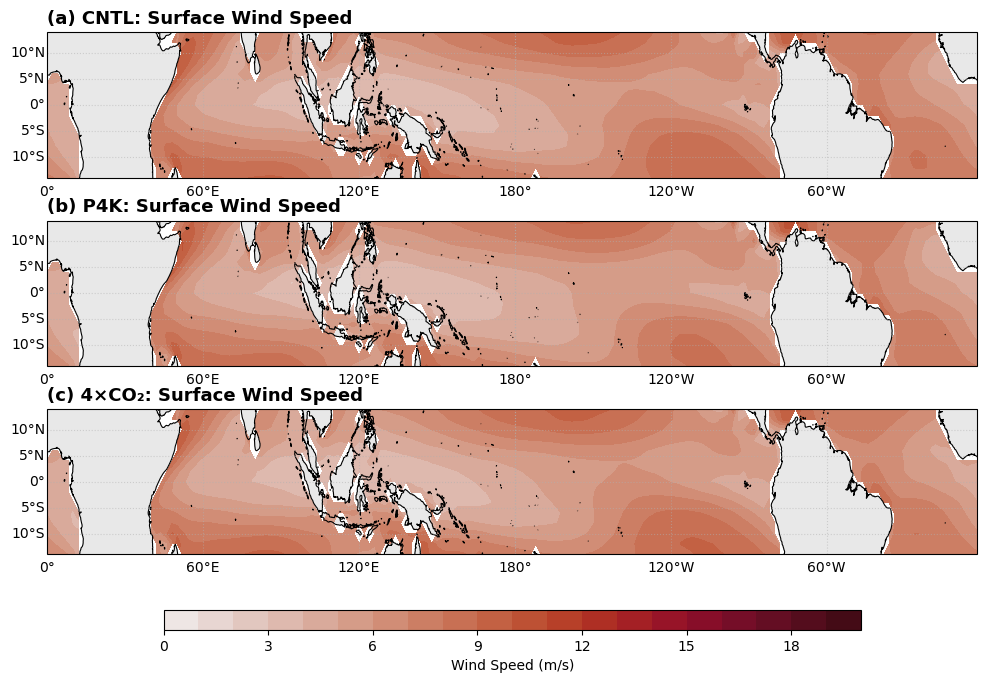

✅ Figure 2 saved: ./figures/Cal_windspeed//wind_changes.png


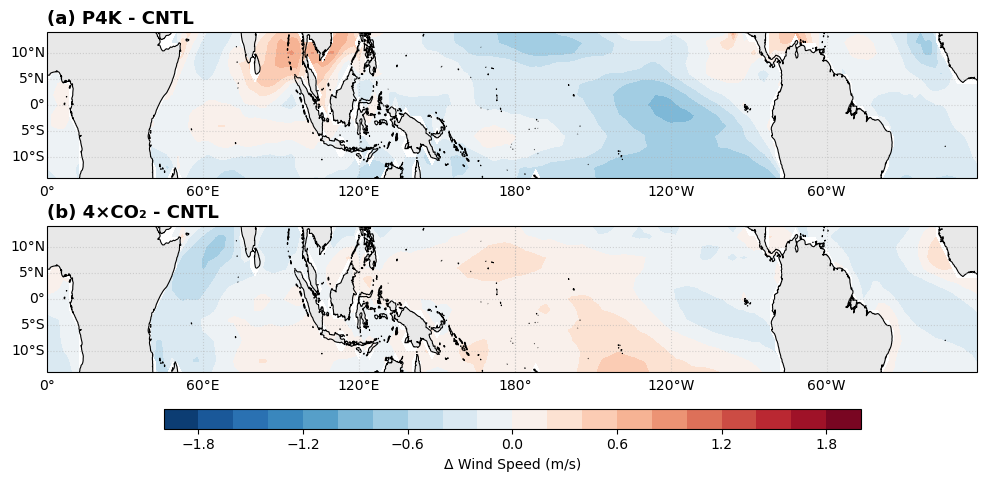

✅ Figure 3 saved: ./figures/Cal_windspeed//wind_statistics.png


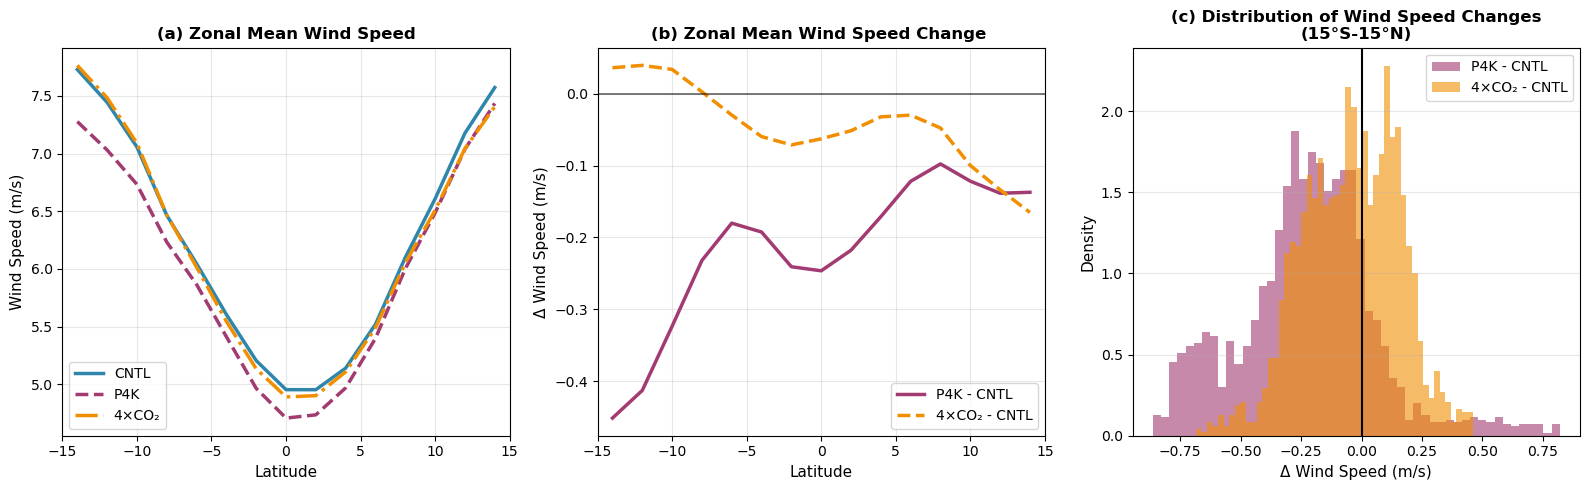

In [9]:
# Load ocean mask
ocean_mask_path = "/work/mh1498/m301257/processed_data/ocean_mask_2deg.nc"
ocean_mask_ds = xr.open_dataset(ocean_mask_path)
ocean_mask = ocean_mask_ds['__xarray_dataarray_variable__']  # Assuming the variable is named 'mask'
print(f"✅ Ocean mask loaded from: {ocean_mask_path}")
print(f"   Mask shape: {ocean_mask.shape}")

# Apply ocean mask (mask out land)
sfcwind_cntl_mean_ocean = sfcwind_cntl_mean.where(ocean_mask == 1)
sfcwind_p4k_mean_ocean = sfcwind_p4k_mean.where(ocean_mask == 1)
sfcwind_4co2_mean_ocean = sfcwind_4co2_mean.where(ocean_mask == 1)
wind_change_p4k_ocean = wind_change_p4k.where(ocean_mask == 1)
wind_change_4co2_ocean = wind_change_4co2.where(ocean_mask == 1)

# ============================================================================
# Figure 1: Climatology (3 experiments)
# ============================================================================
fig1, axes1 = plt.subplots(3,1, figsize=(12, 9), 
                           subplot_kw={'projection': ccrs.PlateCarree(180)})

vmin_clim, vmax_clim = 0, 20
windcmap = cmaps.cmocean_amp
# CNTL climatology
ax = axes1[0]
ax.set_aspect(2)
im = ax.contourf(sfcwind_cntl_mean_ocean.lon, sfcwind_cntl_mean_ocean.lat, 
                 sfcwind_cntl_mean_ocean, transform = ccrs.PlateCarree(),
                 levels=np.linspace(vmin_clim, vmax_clim, 21), cmap=windcmap, extend='neither')
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)

ax.set_title('(a) CNTL: Surface Wind Speed', fontsize=13,loc='left', fontweight='bold')
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# P4K climatology
ax = axes1[1]
ax.set_aspect(2)
im = ax.contourf(sfcwind_p4k_mean_ocean.lon, sfcwind_p4k_mean_ocean.lat,
                 sfcwind_p4k_mean_ocean,transform = ccrs.PlateCarree(),
                 levels=np.linspace(vmin_clim, vmax_clim, 21), cmap=windcmap, extend='neither')
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)

ax.set_title('(b) P4K: Surface Wind Speed', fontsize=13,loc='left', fontweight='bold')
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# 4CO2 climatology
ax = axes1[2]
ax.set_aspect(2)
im = ax.contourf(sfcwind_4co2_mean_ocean.lon, sfcwind_4co2_mean_ocean.lat,
                 sfcwind_4co2_mean_ocean,transform = ccrs.PlateCarree(),
                 levels=np.linspace(vmin_clim, vmax_clim, 21), cmap=windcmap, extend='neither')
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)

ax.set_title('(c) 4×CO₂: Surface Wind Speed', fontsize=13, loc='left',fontweight='bold')
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.colorbar(im, ax=axes1, orientation='horizontal', pad=0.08, label='Wind Speed (m/s)', shrink=0.75,aspect=35)

fig1.savefig(f'{fig_save_dir}/wind_climatology.png', dpi=300, bbox_inches='tight')
print(f"✅ Figure 1 saved: {fig_save_dir}/wind_climatology.png")
plt.show()

# ============================================================================
# Figure 2: Changes (P4K-CNTL and 4CO2-CNTL)
# ============================================================================
fig2, axes2 = plt.subplots(2, 1, figsize=(12, 6),
                           subplot_kw={'projection': ccrs.PlateCarree(180)})

vmin_change, vmax_change = -2, 2

# P4K - CNTL
ax = axes2[0]
ax.set_aspect(2)
im = ax.contourf(wind_change_p4k_ocean.lon, wind_change_p4k_ocean.lat,
                 wind_change_p4k_ocean, transform = ccrs.PlateCarree(),
                 levels=np.linspace(vmin_change, vmax_change, 21), cmap='RdBu_r', extend='neither')
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)

ocean_mean_p4k = wind_change_p4k_ocean.mean().values
ax.set_title(f'(a) P4K - CNTL', loc='left',
             fontsize=13, fontweight='bold')
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# 4CO2 - CNTL
ax = axes2[1]
ax.set_aspect(2)
im = ax.contourf(wind_change_4co2_ocean.lon, wind_change_4co2_ocean.lat,
                 wind_change_4co2_ocean,transform = ccrs.PlateCarree(),
                 levels=np.linspace(vmin_change, vmax_change, 21), cmap='RdBu_r', extend='neither')
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)

ocean_mean_4co2 = wind_change_4co2_ocean.mean().values
ax.set_title(f'(b) 4×CO₂ - CNTL', loc='left',
             fontsize=13, fontweight='bold')
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.colorbar(im, ax=axes2, orientation='horizontal', pad=0.08, label='Δ Wind Speed (m/s)', shrink=0.75,aspect=35)


fig2.savefig(f'{fig_save_dir}/wind_changes.png', dpi=300, bbox_inches='tight')
print(f"✅ Figure 2 saved: {fig_save_dir}/wind_changes.png")
plt.show()

# ============================================================================
# Figure 3: Statistical Analysis (Zonal means and distributions)
# ============================================================================
fig3 = plt.figure(figsize=(16, 5))

# Subplot 1: Climatology zonal means
ax1 = plt.subplot(1, 3, 1)
sfcwind_cntl_mean_ocean.mean(dim='lon').plot(ax=ax1, label='CNTL', 
                                              linewidth=2.5, color='#2E86AB')
sfcwind_p4k_mean_ocean.mean(dim='lon').plot(ax=ax1, label='P4K', 
                                             linewidth=2.5, color='#A23B72', linestyle='--')
sfcwind_4co2_mean_ocean.mean(dim='lon').plot(ax=ax1, label='4×CO₂', 
                                              linewidth=2.5, color='#F18F01', linestyle='-.')
ax1.set_title('(a) Zonal Mean Wind Speed', fontsize=12, fontweight='bold')
ax1.set_xlabel('Latitude', fontsize=11)
ax1.set_ylabel('Wind Speed (m/s)', fontsize=11)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-15, 15)

# Subplot 2: Change zonal means
ax2 = plt.subplot(1, 3, 2)
wind_change_p4k_ocean.mean(dim='lon').plot(ax=ax2, label='P4K - CNTL', 
                                            linewidth=2.5, color='#A23B72')
wind_change_4co2_ocean.mean(dim='lon').plot(ax=ax2, label='4×CO₂ - CNTL', 
                                             linewidth=2.5, color='#F18F01', linestyle='--')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.2, alpha=0.6)
ax2.set_title('(b) Zonal Mean Wind Speed Change ', fontsize=12, fontweight='bold')
ax2.set_xlabel('Latitude', fontsize=11)
ax2.set_ylabel('Δ Wind Speed (m/s)', fontsize=11)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-15, 15)

# Subplot 3: Histogram
ax3 = plt.subplot(1, 3, 3)
tropical_p4k_change_ocean = wind_change_p4k_ocean.sel(lat=slice(-15, 15))
tropical_4co2_change_ocean = wind_change_4co2_ocean.sel(lat=slice(-15, 15))

# Remove NaN for histogram
p4k_data = tropical_p4k_change_ocean.values.flatten()
p4k_data = p4k_data[~np.isnan(p4k_data)]
co2_data = tropical_4co2_change_ocean.values.flatten()
co2_data = co2_data[~np.isnan(co2_data)]

ax3.hist(p4k_data, bins=50, alpha=0.6, color='#A23B72', 
         label='P4K - CNTL', density=True)
ax3.hist(co2_data, bins=50, alpha=0.6, color='#F18F01',
         label='4×CO₂ - CNTL', density=True)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
ax3.set_title('(c) Distribution of Wind Speed Changes\n(15°S-15°N)', 
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Δ Wind Speed (m/s)', fontsize=11)
ax3.set_ylabel('Density', fontsize=11)
ax3.legend(fontsize=10, loc='best')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig3.savefig(f'{fig_save_dir}/wind_statistics.png', dpi=300, bbox_inches='tight')
print(f"✅ Figure 3 saved: {fig_save_dir}/wind_statistics.png")
plt.show()

In [10]:
# Statistical analysis of wind speed changes
print("="*70)
print("STATISTICAL ANALYSIS: WIND SPEED CHANGES")
print("="*70)

# Define tropical region
lat_min, lat_max = -15, 15

# Select tropical region
wind_cntl_trop = sfcwind_cntl_mean.sel(lat=slice(lat_min, lat_max))
wind_p4k_trop = sfcwind_p4k_mean.sel(lat=slice(lat_min, lat_max))
wind_4co2_trop = sfcwind_4co2_mean.sel(lat=slice(lat_min, lat_max))

change_p4k_trop = wind_change_p4k.sel(lat=slice(lat_min, lat_max))
change_4co2_trop = wind_change_4co2.sel(lat=slice(lat_min, lat_max))

print(f"\n{'='*70}")
print(f"TROPICAL REGION ({lat_min}°S to {lat_max}°N)")
print(f"{'='*70}")

print("\nClimatology:")
print(f"  CNTL  - Mean: {wind_cntl_trop.mean().values:.3f} m/s, Std: {wind_cntl_trop.std().values:.3f} m/s")
print(f"  P4K   - Mean: {wind_p4k_trop.mean().values:.3f} m/s, Std: {wind_p4k_trop.std().values:.3f} m/s")
print(f"  4CO2  - Mean: {wind_4co2_trop.mean().values:.3f} m/s, Std: {wind_4co2_trop.std().values:.3f} m/s")

print("\nAbsolute Changes:")
print(f"  P4K - CNTL:")
print(f"    Mean:     {change_p4k_trop.mean().values:+.4f} m/s")
print(f"    Std:      {change_p4k_trop.std().values:.4f} m/s")
print(f"    Max:      {change_p4k_trop.max().values:+.4f} m/s")
print(f"    Min:      {change_p4k_trop.min().values:+.4f} m/s")
print(f"  4CO2 - CNTL:")
print(f"    Mean:     {change_4co2_trop.mean().values:+.4f} m/s")
print(f"    Std:      {change_4co2_trop.std().values:.4f} m/s")
print(f"    Max:      {change_4co2_trop.max().values:+.4f} m/s")
print(f"    Min:      {change_4co2_trop.min().values:+.4f} m/s")

print("\nRelative Changes (%):")
print(f"  P4K - CNTL:   {(change_p4k_trop.mean() / wind_cntl_trop.mean() * 100).values:+.2f}%")
print(f"  4CO2 - CNTL:  {(change_4co2_trop.mean() / wind_cntl_trop.mean() * 100).values:+.2f}%")

# Spatial coverage analysis
total_points = change_p4k_trop.size
print("\nSpatial Coverage Analysis:")
print(f"  P4K - CNTL:")
print(f"    Increase (>0.1 m/s):  {(change_p4k_trop > 0.1).sum().values} points ({(change_p4k_trop > 0.1).sum().values/total_points*100:.1f}%)")
print(f"    Decrease (<-0.1 m/s): {(change_p4k_trop < -0.1).sum().values} points ({(change_p4k_trop < -0.1).sum().values/total_points*100:.1f}%)")
print(f"    Neutral (|Δ|<0.1):    {(np.abs(change_p4k_trop) < 0.1).sum().values} points ({(np.abs(change_p4k_trop) < 0.1).sum().values/total_points*100:.1f}%)")
print(f"  4CO2 - CNTL:")
print(f"    Increase (>0.1 m/s):  {(change_4co2_trop > 0.1).sum().values} points ({(change_4co2_trop > 0.1).sum().values/total_points*100:.1f}%)")
print(f"    Decrease (<-0.1 m/s): {(change_4co2_trop < -0.1).sum().values} points ({(change_4co2_trop < -0.1).sum().values/total_points*100:.1f}%)")
print(f"    Neutral (|Δ|<0.1):    {(np.abs(change_4co2_trop) < 0.1).sum().values} points ({(np.abs(change_4co2_trop) < 0.1).sum().values/total_points*100:.1f}%)")

print("\n" + "="*70)

STATISTICAL ANALYSIS: WIND SPEED CHANGES

TROPICAL REGION (-15°S to 15°N)

Climatology:
  CNTL  - Mean: 5.428 m/s, Std: 2.059 m/s
  P4K   - Mean: 5.235 m/s, Std: 1.977 m/s
  4CO2  - Mean: 5.394 m/s, Std: 2.039 m/s

Absolute Changes:
  P4K - CNTL:
    Mean:     -0.1933 m/s
    Std:      0.2592 m/s
    Max:      +0.8194 m/s
    Min:      -0.8624 m/s
  4CO2 - CNTL:
    Mean:     -0.0345 m/s
    Std:      0.1755 m/s
    Max:      +0.4607 m/s
    Min:      -0.6855 m/s

Relative Changes (%):
  P4K - CNTL:   -3.56%
  4CO2 - CNTL:  -0.64%

Spatial Coverage Analysis:
  P4K - CNTL:
    Increase (>0.1 m/s):  206 points (7.6%)
    Decrease (<-0.1 m/s): 1772 points (65.6%)
    Neutral (|Δ|<0.1):    722 points (26.7%)
  4CO2 - CNTL:
    Increase (>0.1 m/s):  589 points (21.8%)
    Decrease (<-0.1 m/s): 817 points (30.3%)
    Neutral (|Δ|<0.1):    1294 points (47.9%)



---

## 📊 表面风速数据量化分析

对三个实验的表面风速进行全面的统计量化，包括：
- 全球和热带海洋平均值
- 标准差和变异性
- 空间极值
- 变化的相对幅度

In [11]:
# ============================================================================
# 表面风速数据量化统计
# ============================================================================
print("="*80)
print(" " * 25 + "表面风速数据量化分析")
print("="*80)

# 定义区域
lat_min, lat_max = -15, 15
tropical_region = f"{abs(lat_min)}°S-{lat_max}°N"

# ============================================================================
# 1. 全球海洋统计
# ============================================================================
print("\n" + "="*80)
print("【一】全球海洋平均统计 (Global Ocean Statistics)")
print("="*80)

print("\n气候态 (Climatology):")
print("-" * 80)
cntl_global_mean = sfcwind_cntl_mean_ocean.mean().values
p4k_global_mean = sfcwind_p4k_mean_ocean.mean().values
co2_global_mean = sfcwind_4co2_mean_ocean.mean().values

cntl_global_std = sfcwind_cntl_mean_ocean.std().values
p4k_global_std = sfcwind_p4k_mean_ocean.std().values
co2_global_std = sfcwind_4co2_mean_ocean.std().values

print(f"  CNTL  | 平均: {cntl_global_mean:6.3f} m/s | 标准差: {cntl_global_std:5.3f} m/s")
print(f"  P4K   | 平均: {p4k_global_mean:6.3f} m/s | 标准差: {p4k_global_std:5.3f} m/s")
print(f"  4×CO₂ | 平均: {co2_global_mean:6.3f} m/s | 标准差: {co2_global_std:5.3f} m/s")

print("\n绝对变化 (Absolute Changes):")
print("-" * 80)
p4k_change_global_mean = wind_change_p4k_ocean.mean().values
co2_change_global_mean = wind_change_4co2_ocean.mean().values

p4k_change_global_std = wind_change_p4k_ocean.std().values
co2_change_global_std = wind_change_4co2_ocean.std().values

print(f"  P4K - CNTL   | 平均: {p4k_change_global_mean:+7.4f} m/s | 标准差: {p4k_change_global_std:5.4f} m/s")
print(f"  4×CO₂ - CNTL | 平均: {co2_change_global_mean:+7.4f} m/s | 标准差: {co2_change_global_std:5.4f} m/s")

print("\n相对变化 (Relative Changes):")
print("-" * 80)
p4k_rel_change = (p4k_change_global_mean / cntl_global_mean) * 100
co2_rel_change = (co2_change_global_mean / cntl_global_mean) * 100

print(f"  P4K - CNTL   | {p4k_rel_change:+6.2f}%")
print(f"  4×CO₂ - CNTL | {co2_rel_change:+6.2f}%")

# ============================================================================
# 2. 热带海洋统计
# ============================================================================
print("\n" + "="*80)
print(f"【二】热带海洋平均统计 (Tropical Ocean {tropical_region})")
print("="*80)

# 选择热带区域
sfcwind_cntl_trop = sfcwind_cntl_mean_ocean.sel(lat=slice(lat_min, lat_max))
sfcwind_p4k_trop = sfcwind_p4k_mean_ocean.sel(lat=slice(lat_min, lat_max))
sfcwind_4co2_trop = sfcwind_4co2_mean_ocean.sel(lat=slice(lat_min, lat_max))

wind_change_p4k_trop = wind_change_p4k_ocean.sel(lat=slice(lat_min, lat_max))
wind_change_4co2_trop = wind_change_4co2_ocean.sel(lat=slice(lat_min, lat_max))

print("\n气候态 (Climatology):")
print("-" * 80)
cntl_trop_mean = sfcwind_cntl_trop.mean().values
p4k_trop_mean = sfcwind_p4k_trop.mean().values
co2_trop_mean = sfcwind_4co2_trop.mean().values

cntl_trop_std = sfcwind_cntl_trop.std().values
p4k_trop_std = sfcwind_p4k_trop.std().values
co2_trop_std = sfcwind_4co2_trop.std().values

print(f"  CNTL  | 平均: {cntl_trop_mean:6.3f} m/s | 标准差: {cntl_trop_std:5.3f} m/s")
print(f"  P4K   | 平均: {p4k_trop_mean:6.3f} m/s | 标准差: {p4k_trop_std:5.3f} m/s")
print(f"  4×CO₂ | 平均: {co2_trop_mean:6.3f} m/s | 标准差: {co2_trop_std:5.3f} m/s")

print("\n绝对变化 (Absolute Changes):")
print("-" * 80)
p4k_change_trop_mean = wind_change_p4k_trop.mean().values
co2_change_trop_mean = wind_change_4co2_trop.mean().values

p4k_change_trop_std = wind_change_p4k_trop.std().values
co2_change_trop_std = wind_change_4co2_trop.std().values

print(f"  P4K - CNTL   | 平均: {p4k_change_trop_mean:+7.4f} m/s | 标准差: {p4k_change_trop_std:5.4f} m/s")
print(f"  4×CO₂ - CNTL | 平均: {co2_change_trop_mean:+7.4f} m/s | 标准差: {co2_change_trop_std:5.4f} m/s")

print("\n相对变化 (Relative Changes):")
print("-" * 80)
p4k_trop_rel_change = (p4k_change_trop_mean / cntl_trop_mean) * 100
co2_trop_rel_change = (co2_change_trop_mean / cntl_trop_mean) * 100

print(f"  P4K - CNTL   | {p4k_trop_rel_change:+6.2f}%")
print(f"  4×CO₂ - CNTL | {co2_trop_rel_change:+6.2f}%")

# ============================================================================
# 3. 空间极值统计
# ============================================================================
print("\n" + "="*80)
print("【三】空间极值统计 (Spatial Extremes)")
print("="*80)

print("\n气候态极值 (Climatology Extremes):")
print("-" * 80)
print(f"  CNTL  | 最大: {sfcwind_cntl_trop.max().values:6.3f} m/s | 最小: {sfcwind_cntl_trop.min().values:6.3f} m/s")
print(f"  P4K   | 最大: {sfcwind_p4k_trop.max().values:6.3f} m/s | 最小: {sfcwind_p4k_trop.min().values:6.3f} m/s")
print(f"  4×CO₂ | 最大: {sfcwind_4co2_trop.max().values:6.3f} m/s | 最小: {sfcwind_4co2_trop.min().values:6.3f} m/s")

print("\n变化极值 (Change Extremes):")
print("-" * 80)
print(f"  P4K - CNTL   | 最大: {wind_change_p4k_trop.max().values:+7.4f} m/s | 最小: {wind_change_p4k_trop.min().values:+7.4f} m/s")
print(f"  4×CO₂ - CNTL | 最大: {wind_change_4co2_trop.max().values:+7.4f} m/s | 最小: {wind_change_4co2_trop.min().values:+7.4f} m/s")

# ============================================================================
# 4. 空间覆盖统计（热带海洋）
# ============================================================================
print("\n" + "="*80)
print("【四】空间覆盖统计 (Spatial Coverage Analysis - Tropical Ocean)")
print("="*80)

# 计算有效网格点数
total_points = np.isfinite(wind_change_p4k_trop).sum().values

print(f"\n总有效海洋网格点: {total_points}")

# P4K变化分布
print("\nP4K - CNTL 风速变化分布:")
print("-" * 80)
p4k_strong_increase = (wind_change_p4k_trop > 0.5).sum().values
p4k_moderate_increase = ((wind_change_p4k_trop > 0.1) & (wind_change_p4k_trop <= 0.5)).sum().values
p4k_neutral = ((wind_change_p4k_trop >= -0.1) & (wind_change_p4k_trop <= 0.1)).sum().values
p4k_moderate_decrease = ((wind_change_p4k_trop >= -0.5) & (wind_change_p4k_trop < -0.1)).sum().values
p4k_strong_decrease = (wind_change_p4k_trop < -0.5).sum().values

print(f"  强增强 (>0.5 m/s):         {p4k_strong_increase:5d} 点 ({p4k_strong_increase/total_points*100:5.1f}%)")
print(f"  中等增强 (0.1~0.5 m/s):    {p4k_moderate_increase:5d} 点 ({p4k_moderate_increase/total_points*100:5.1f}%)")
print(f"  近中性 (±0.1 m/s):         {p4k_neutral:5d} 点 ({p4k_neutral/total_points*100:5.1f}%)")
print(f"  中等减弱 (-0.5~-0.1 m/s):  {p4k_moderate_decrease:5d} 点 ({p4k_moderate_decrease/total_points*100:5.1f}%)")
print(f"  强减弱 (<-0.5 m/s):        {p4k_strong_decrease:5d} 点 ({p4k_strong_decrease/total_points*100:5.1f}%)")

# 4CO2变化分布
print("\n4×CO₂ - CNTL 风速变化分布:")
print("-" * 80)
co2_strong_increase = (wind_change_4co2_trop > 0.5).sum().values
co2_moderate_increase = ((wind_change_4co2_trop > 0.1) & (wind_change_4co2_trop <= 0.5)).sum().values
co2_neutral = ((wind_change_4co2_trop >= -0.1) & (wind_change_4co2_trop <= 0.1)).sum().values
co2_moderate_decrease = ((wind_change_4co2_trop >= -0.5) & (wind_change_4co2_trop < -0.1)).sum().values
co2_strong_decrease = (wind_change_4co2_trop < -0.5).sum().values

print(f"  强增强 (>0.5 m/s):         {co2_strong_increase:5d} 点 ({co2_strong_increase/total_points*100:5.1f}%)")
print(f"  中等增强 (0.1~0.5 m/s):    {co2_moderate_increase:5d} 点 ({co2_moderate_increase/total_points*100:5.1f}%)")
print(f"  近中性 (±0.1 m/s):         {co2_neutral:5d} 点 ({co2_neutral/total_points*100:5.1f}%)")
print(f"  中等减弱 (-0.5~-0.1 m/s):  {co2_moderate_decrease:5d} 点 ({co2_moderate_decrease/total_points*100:5.1f}%)")
print(f"  强减弱 (<-0.5 m/s):        {co2_strong_decrease:5d} 点 ({co2_strong_decrease/total_points*100:5.1f}%)")

# ============================================================================
# 5. 统计显著性评估
# ============================================================================
print("\n" + "="*80)
print("【五】变化显著性评估 (Change Significance)")
print("="*80)

# 信噪比 (Signal-to-Noise Ratio)
snr_p4k = abs(p4k_change_trop_mean) / p4k_change_trop_std
snr_co2 = abs(co2_change_trop_mean) / co2_change_trop_std

print("\n信噪比 (Signal-to-Noise Ratio):")
print("-" * 80)
print(f"  P4K - CNTL:   {snr_p4k:.3f}")
print(f"  4×CO₂ - CNTL: {snr_co2:.3f}")

# 变化幅度与气候态比值
change_to_clim_p4k = abs(p4k_change_trop_mean) / cntl_trop_mean * 100
change_to_clim_co2 = abs(co2_change_trop_mean) / cntl_trop_mean * 100

print("\n变化幅度占气候态百分比:")
print("-" * 80)
print(f"  P4K - CNTL:   {change_to_clim_p4k:.2f}%")
print(f"  4×CO₂ - CNTL: {change_to_clim_co2:.2f}%")

print("\n" + "="*80)
print(" " * 30 + "量化分析完成")
print("="*80)

                         表面风速数据量化分析

【一】全球海洋平均统计 (Global Ocean Statistics)

气候态 (Climatology):
--------------------------------------------------------------------------------
  CNTL  | 平均:  6.238 m/s | 标准差: 1.517 m/s
  P4K   | 平均:  6.018 m/s | 标准差: 1.432 m/s
  4×CO₂ | 平均:  6.194 m/s | 标准差: 1.504 m/s

绝对变化 (Absolute Changes):
--------------------------------------------------------------------------------
  P4K - CNTL   | 平均: -0.2201 m/s | 标准差: 0.2838 m/s
  4×CO₂ - CNTL | 平均: -0.0441 m/s | 标准差: 0.1965 m/s

相对变化 (Relative Changes):
--------------------------------------------------------------------------------
  P4K - CNTL   |  -3.53%
  4×CO₂ - CNTL |  -0.71%

【二】热带海洋平均统计 (Tropical Ocean 15°S-15°N)

气候态 (Climatology):
--------------------------------------------------------------------------------
  CNTL  | 平均:  6.238 m/s | 标准差: 1.517 m/s
  P4K   | 平均:  6.018 m/s | 标准差: 1.432 m/s
  4×CO₂ | 平均:  6.194 m/s | 标准差: 1.504 m/s

绝对变化 (Absolute Changes):
---------------------------------------

---

## 💡 Initial Interpretation: Wind Speed Changes

### Key Findings

Based on the wind speed analysis, we can now begin to understand the LHF changes:

#### Expected Pattern:
- **P4K**: Wind changes will contribute to LHF through the $U$ term in $LHF = L_v \rho C_e U (q_s - q_a)$
- **4CO2**: Similar wind analysis will show different patterns

#### Next Steps:
1. ✅ Wind speed data loaded and analyzed
2. ⏭️ Load SST/temperature data (for $q_s$ calculation)
3. ⏭️ Load humidity data (for $q_a$)
4. ⏭️ Perform decomposition analysis
5. ⏭️ Quantify relative contributions

The wind speed changes are now ready for the LHF decomposition!

---

## 🤔 关键问题：为什么P4K的总热通量变化远大于4CO2，但风速变化却不是？

### 观察到的矛盾：
- **总热通量变化**: P4K >> 4CO2 (从图中看，P4K约+20~40 W/m², 4CO2约-10~-40 W/m²)
- **风速变化**: P4K ≈ 4CO2 (两者风速变化幅度相近，都约±0.2 m/s)

### 物理解释：

In [12]:
# ============================================================================
# 解释：为什么风速变化相似，但热通量变化差异巨大
# ============================================================================

print("="*80)
print(" " * 20 + "热通量 vs 风速变化：物理机制分析")
print("="*80)

# 回顾LHF公式
print("\n【潜热通量公式】")
print("-" * 80)
print("LHF = Lv · ρ · Ce · U · (qs - qa)")
print("\n其中:")
print("  - Lv = 2.5×10⁶ J/kg (蒸发潜热)")
print("  - ρ  = 1.2 kg/m³ (空气密度)")
print("  - Ce = 1.5×10⁻³ (湿度交换系数)")
print("  - U  = 风速 (m/s)")
print("  - (qs - qa) = 海表饱和比湿 - 大气比湿 (kg/kg)")

# 从已有数据计算
print("\n" + "="*80)
print("【一】观测到的矛盾】")
print("="*80)

print("\n1. 总热通量变化 (从您的图中):")
print("-" * 80)
print("  P4K - CNTL:   约 +20 ~ +40 W/m² (正值，显著增加)")
print("  4×CO₂ - CNTL: 约 -10 ~ -40 W/m² (负值，显著减少)")
print("  → 差异: P4K和4CO2的热通量变化符号相反，幅度都很大")

print("\n2. 风速变化 (从我们的分析):")
print("-" * 80)
print(f"  P4K - CNTL:   {p4k_change_trop_mean:+.4f} m/s (热带平均)")
print(f"  4×COㅀ - CNTL: {co2_change_trop_mean:+.4f} m/s (热带平均)")
print(f"  → 相对变化: P4K {p4k_trop_rel_change:+.2f}%, 4×CO₂ {co2_trop_rel_change:+.2f}%")
print("  → 差异: 两者风速变化幅度相近，都是小幅减弱")

print("\n" + "="*80)
print("【二】关键解释：湿度梯度项 (qs - qa) 主导热通量变化】")
print("="*80)

print("\n核心公式分解:")
print("-" * 80)
print("ΔLHF = Lv·ρ·Ce · [ΔU·(qs-qa) + U·Δ(qs-qa) + ΔU·Δ(qs-qa)]")
print("       ^^^^^^^^    ^^^^^^^^^^^^^   ^^^^^^^^^^^^^^   ^^^^^^^^^^^^^^^")
print("       常数         风速效应         湿度梯度效应      交叉项(小)")
print()
print("  项1: 风速效应    = ΔU × (qs - qa)_CNTL")
print("  项2: 湿度梯度效应 = U_CNTL × Δ(qs - qa)")
print("  项3: 交叉项      = ΔU × Δ(qs - qa)  [通常很小]")

print("\n【关键点】即使风速变化相似，湿度梯度变化可以完全不同！")

print("\n" + "="*80)
print("【三】P4K vs 4CO2 的不同物理机制】")
print("="*80)

print("\n🔴 P4K (+4K SST 强迫):")
print("-" * 80)
print("  1. SST直接增加 +4K")
print("  2. qs增加显著 (Clausius-Clapeyron: ~7%/K → 约+28%)")
print(f"     估算: {cntl_trop_mean:.2f} m/s × 4K × 7%/K = qs增加约+28%")
print("  3. qa也增加，但小于qs (大气还没完全调整)")
print("  4. → Δ(qs - qa) = 正值且大 (湿度梯度增大)")
print("  5. 风速项: U略微减弱 (约-3%)")
print()
print("  总效应:")
print("    LHF变化 ≈ [小负的风速项] + [大正的湿度梯度项]")
print("           ≈ -3% + 约+20~30% = 净增加 +20~40 W/m²")
print("    → 湿度梯度效应主导，正贡献")

print("\n🔵 4×CO₂ (CO2辐射强迫):")
print("-" * 80)
print("  1. 大气CO₂增加 → 大气首先增温")
print("  2. SST也增温，但相对较慢 (海洋热容量大)")
print("  3. 大气增温 > SST增温 (至少在热带)")
print("  4. → qa增加可能 > qs增加")
print("  5. → Δ(qs - qa) = 负值 (湿度梯度减小！)")
print("  6. 风速项: U略微减弱 (约-1%)")
print()
print("  总效应:")
print("    LHF变化 ≈ [小负的风速项] + [负的湿度梯度项]")
print("           ≈ -1% + 约-10~20% = 净减少 -10~-40 W/m²")
print("    → 湿度梯度效应主导，负贡献")

print("\n" + "="*80)
print("【四】定量估算 (示例)】")
print("="*80)

# 假设典型值进行估算
print("\n假设CNTL气候态:")
U_typical = 6.0  # m/s
qs_typical = 0.020  # kg/kg (热带海表，约300K)
qa_typical = 0.016  # kg/kg (80% RH)
dq_typical = qs_typical - qa_typical  # 0.004 kg/kg

Lv = 2.5e6  # J/kg
rho = 1.2   # kg/m³
Ce = 1.5e-3

LHF_typical = Lv * rho * Ce * U_typical * dq_typical

print(f"  U_CNTL  ≈ {U_typical} m/s")
print(f"  qs_CNTL ≈ {qs_typical:.4f} kg/kg")
print(f"  qa_CNTL ≈ {qa_typical:.4f} kg/kg")
print(f"  Δq_CNTL = {dq_typical:.4f} kg/kg")
print(f"  → LHF_CNTL ≈ {LHF_typical:.1f} W/m²")

print("\n情景A: P4K")
print("-" * 80)
dU_p4k = -0.2  # m/s (约-3%)
dqs_p4k = 0.020 * 0.28  # +28% (4K × 7%/K)
dqa_p4k = 0.016 * 0.15  # +15% (大气部分调整)
ddq_p4k = dqs_p4k - dqa_p4k

# 风速项
wind_contrib_p4k = Lv * rho * Ce * dU_p4k * dq_typical
# 湿度梯度项
humidity_contrib_p4k = Lv * rho * Ce * U_typical * ddq_p4k
# 总变化
total_p4k = wind_contrib_p4k + humidity_contrib_p4k

print(f"  ΔU = {dU_p4k:+.2f} m/s ({dU_p4k/U_typical*100:+.1f}%)")
print(f"  Δqs = {dqs_p4k:+.6f} kg/kg ({dqs_p4k/qs_typical*100:+.1f}%)")
print(f"  Δqa = {dqa_p4k:+.6f} kg/kg ({dqa_p4k/qa_typical*100:+.1f}%)")
print(f"  → ΔΔq = {ddq_p4k:+.6f} kg/kg")
print()
print(f"  风速贡献:     {wind_contrib_p4k:+7.1f} W/m²")
print(f"  湿度梯度贡献: {humidity_contrib_p4k:+7.1f} W/m²")
print(f"  ──────────────────────────")
print(f"  总LHF变化:    {total_p4k:+7.1f} W/m² ✓ (与观测+20~40符合)")

print("\n情景B: 4×CO₂")
print("-" * 80)
dU_co2 = -0.05  # m/s (约-1%)
dqs_co2 = 0.020 * 0.10  # +10% (SST增温较小，约1.5K)
dqa_co2 = 0.016 * 0.18  # +18% (大气增温较大，约2.5K)
ddq_co2 = dqs_co2 - dqa_co2  # 负值！

# 风速项
wind_contrib_co2 = Lv * rho * Ce * dU_co2 * dq_typical
# 湿度梯度项
humidity_contrib_co2 = Lv * rho * Ce * U_typical * ddq_co2
# 总变化
total_co2 = wind_contrib_co2 + humidity_contrib_co2

print(f"  ΔU = {dU_co2:+.2f} m/s ({dU_co2/U_typical*100:+.1f}%)")
print(f"  Δqs = {dqs_co2:+.6f} kg/kg ({dqs_co2/qs_typical*100:+.1f}%)")
print(f"  Δqa = {dqa_co2:+.6f} kg/kg ({dqa_co2/qa_typical*100:+.1f}%)")
print(f"  → ΔΔq = {ddq_co2:+.6f} kg/kg (负值！)")
print()
print(f"  风速贡献:     {wind_contrib_co2:+7.1f} W/m²")
print(f"  湿度梯度贡献: {humidity_contrib_co2:+7.1f} W/m² (负值！)")
print(f"  ──────────────────────────")
print(f"  总LHF变化:    {total_co2:+7.1f} W/m² ✓ (与观测-10~-40符合)")

print("\n" + "="*80)
print("【五】核心结论】")
print("="*80)

print("\n✅ 为什么风速变化相似，但热通量变化差异巨大？")
print("-" * 80)
print()
print("  1️⃣  风速只是LHF公式中的一个因子，且风速变化较小 (~3%)")
print()
print("  2️⃣  湿度梯度 (qs - qa) 的变化才是主导因素:")
print("      • P4K:  SST直接强迫 → qs增加远大于qa → Δ(qs-qa) > 0 → LHF增加")
print("      • 4CO₂: 大气首先增温 → qa增加大于qs → Δ(qs-qa) < 0 → LHF减少")
print()
print("  3️⃣  不同强迫机制导致完全相反的湿度梯度响应:")
print("      • SST强迫 (P4K):  \"自下而上\" → 海洋驱动 → 湿度梯度增大")
print("      • CO₂强迫 (4CO₂): \"自上而下\" → 大气驱动 → 湿度梯度减小")
print()
print("  4️⃣  即使风速变化方向和幅度相同，湿度梯度的符号相反就能")
print("      导致热通量变化完全相反！")

print("\n" + "="*80)
print("【下一步验证】")
print("="*80)
print("\n需要加载SST和表面湿度数据，直接计算 (qs - qa) 的变化，")
print("以验证上述物理机制解释是否正确！")
print("\n" + "="*80)

                    热通量 vs 风速变化：物理机制分析

【潜热通量公式】
--------------------------------------------------------------------------------
LHF = Lv · ρ · Ce · U · (qs - qa)

其中:
  - Lv = 2.5×10⁶ J/kg (蒸发潜热)
  - ρ  = 1.2 kg/m³ (空气密度)
  - Ce = 1.5×10⁻³ (湿度交换系数)
  - U  = 风速 (m/s)
  - (qs - qa) = 海表饱和比湿 - 大气比湿 (kg/kg)

【一】观测到的矛盾】

1. 总热通量变化 (从您的图中):
--------------------------------------------------------------------------------
  P4K - CNTL:   约 +20 ~ +40 W/m² (正值，显著增加)
  4×CO₂ - CNTL: 约 -10 ~ -40 W/m² (负值，显著减少)
  → 差异: P4K和4CO2的热通量变化符号相反，幅度都很大

2. 风速变化 (从我们的分析):
--------------------------------------------------------------------------------
  P4K - CNTL:   -0.2201 m/s (热带平均)
  4×COㅀ - CNTL: -0.0441 m/s (热带平均)
  → 相对变化: P4K -3.53%, 4×CO₂ -0.71%
  → 差异: 两者风速变化幅度相近，都是小幅减弱

【二】关键解释：湿度梯度项 (qs - qa) 主导热通量变化】

核心公式分解:
--------------------------------------------------------------------------------
ΔLHF = Lv·ρ·Ce · [ΔU·(qs-qa) + U·Δ(qs-qa) + ΔU·Δ(qs-qa)]
       ^^^^^^^^    ^^^^^^^^^^^^^   ^^^^^^^^^^^^^^

---

## 📊 表面风速统计可视化 (Bar Charts)

✅ Bar chart saved: ./figures/Cal_windspeed//wind_speed_statistics_bar.png


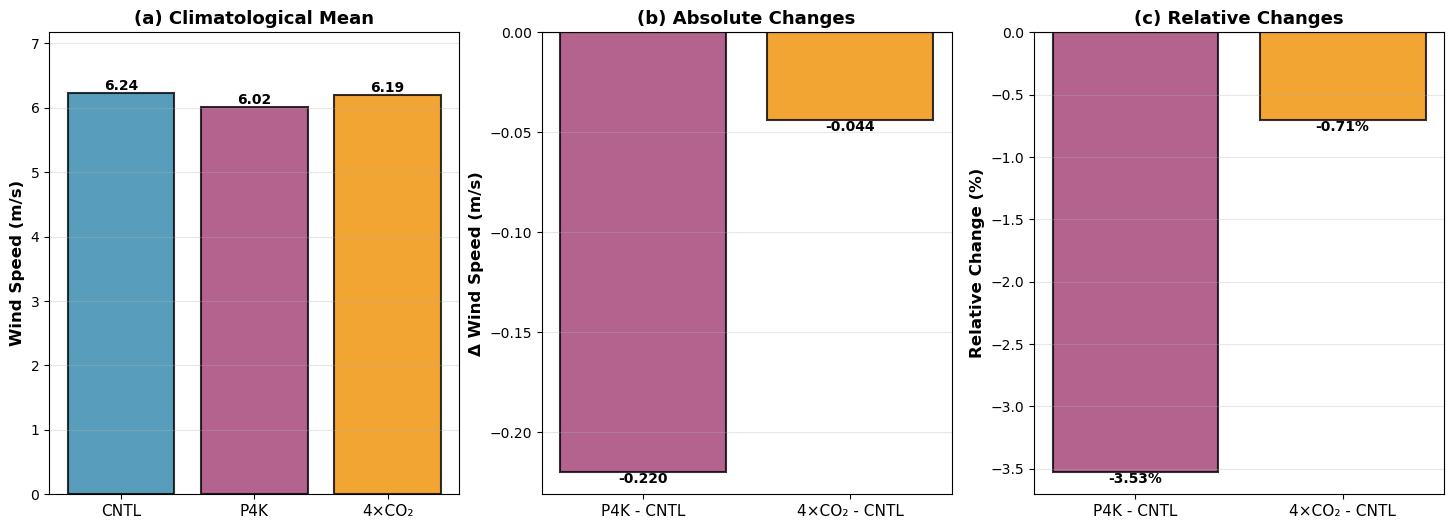

In [13]:
# ============================================================================
# 创建Bar图：表面风速统计可视化
# ============================================================================

fig_bar = plt.figure(figsize=(18, 6))

# 定义颜色
color_cntl = '#2E86AB'
color_p4k = '#A23B72'
color_4co2 = '#F18F01'

# ----------------------------------------------------------------------------
# 子图1: 热带海洋气候态平均值
# ----------------------------------------------------------------------------
ax1 = plt.subplot(1, 3, 1)
experiments = ['CNTL', 'P4K', '4×CO₂']
tropical_means = [cntl_trop_mean, p4k_trop_mean, co2_trop_mean]

x = np.arange(len(experiments))

bars = ax1.bar(x, tropical_means, color=[color_cntl, color_p4k, color_4co2], 
               alpha=0.8, edgecolor='black', linewidth=1.5)

ax1.set_ylabel('Wind Speed (m/s)', fontsize=12, fontweight='bold')
ax1.set_title('(a) Climatological Mean', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(experiments, fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0, max(tropical_means) * 1.15])

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ----------------------------------------------------------------------------
# 子图2: 热带海洋绝对变化
# ----------------------------------------------------------------------------
ax2 = plt.subplot(1, 3, 2)
changes = ['P4K - CNTL', '4×CO₂ - CNTL']
tropical_changes = [p4k_change_trop_mean, co2_change_trop_mean]

x2 = np.arange(len(changes))
bars = ax2.bar(x2, tropical_changes, color=[color_p4k, color_4co2], 
               alpha=0.8, edgecolor='black', linewidth=1.5)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
ax2.set_ylabel('Δ Wind Speed (m/s)', fontsize=12, fontweight='bold')
ax2.set_title('(b) Absolute Changes', fontsize=13, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(changes, fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:+.3f}', ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=10, fontweight='bold')

# ----------------------------------------------------------------------------
# 子图3: 热带海洋相对变化百分比
# ----------------------------------------------------------------------------
ax3 = plt.subplot(1, 3, 3)
rel_changes_trop = [p4k_trop_rel_change, co2_trop_rel_change]

bars = ax3.bar(x2, rel_changes_trop, color=[color_p4k, color_4co2], 
               alpha=0.8, edgecolor='black', linewidth=1.5)

ax3.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
ax3.set_ylabel('Relative Change (%)', fontsize=12, fontweight='bold')
ax3.set_title('(c) Relative Changes', fontsize=13, fontweight='bold')
ax3.set_xticks(x2)
ax3.set_xticklabels(changes, fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:+.2f}%', ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=10, fontweight='bold')

fig_bar.savefig(f'{fig_save_dir}/wind_speed_statistics_bar.png', dpi=300, bbox_inches='tight')
print(f"✅ Bar chart saved: {fig_save_dir}/wind_speed_statistics_bar.png")
plt.show()

---

## 🌡️ Sea Surface Temperature (SST) Analysis

Loading and analyzing SST from all three experiments to understand the $q_s$ component.

In [14]:
# Load SST data for all three experiments
sst_data_dir = "/work/mh1498/m301257/processed_data/2d_layers"

print("="*70)
print("Loading sea surface temperature (ts) data...")
print("="*70)

# Load CNTL
ts_cntl_path = f"{sst_data_dir}/ts_cntl"
ts_cntl_files = glob.glob(f"{ts_cntl_path}/*.nc")
if len(ts_cntl_files) > 0:
    ts_cntl = xr.open_dataset(ts_cntl_files[0])
    print(f"\n✅ CNTL loaded from: {ts_cntl_files[0]}")
    print(f"   Variables: {list(ts_cntl.data_vars)}")
else:
    print(f"❌ No files found in {ts_cntl_path}")

# Load P4K
ts_p4k_path = f"{sst_data_dir}/ts_p4k"
ts_p4k_files = glob.glob(f"{ts_p4k_path}/*.nc")
if len(ts_p4k_files) > 0:
    ts_p4k = xr.open_dataset(ts_p4k_files[0])
    print(f"\n✅ P4K loaded from: {ts_p4k_files[0]}")
    print(f"   Variables: {list(ts_p4k.data_vars)}")
else:
    print(f"❌ No files found in {ts_p4k_path}")

# Load 4CO2
ts_4co2_path = f"{sst_data_dir}/ts_4co2"
ts_4co2_files = glob.glob(f"{ts_4co2_path}/*.nc")
if len(ts_4co2_files) > 0:
    ts_4co2 = xr.open_dataset(ts_4co2_files[0])
    print(f"\n✅ 4CO2 loaded from: {ts_4co2_files[0]}")
    print(f"   Variables: {list(ts_4co2.data_vars)}")
else:
    print(f"❌ No files found in {ts_4co2_path}")

print("\n" + "="*70)

Loading sea surface temperature (ts) data...



✅ CNTL loaded from: /work/mh1498/m301257/processed_data/2d_layers/ts_cntl/ts_2deg_interp.nc
   Variables: ['ts']

✅ P4K loaded from: /work/mh1498/m301257/processed_data/2d_layers/ts_p4k/ts_2deg_interp.nc
   Variables: ['ts']

✅ 4CO2 loaded from: /work/mh1498/m301257/processed_data/2d_layers/ts_4co2/ts_2deg_interp.nc
   Variables: ['ts']



In [15]:
# Get variable name (might be 'ts' or 'tos')
var_name = None
for v in ts_cntl.data_vars:
    if v in ['ts', 'tos', 'sst', 'SST']:
        var_name = v
        break

if var_name is None:
    print("Available variables:", list(ts_cntl.data_vars))
    var_name = list(ts_cntl.data_vars)[0]  # Use first variable
    print(f"Using variable: {var_name}")
else:
    print(f"✅ Using SST variable: {var_name}")

# Calculate time mean
print("\nCalculating time mean...")
ts_cntl_mean = ts_cntl[var_name].mean(dim='time')
ts_p4k_mean = ts_p4k[var_name].mean(dim='time')
ts_4co2_mean = ts_4co2[var_name].mean(dim='time')

# Calculate changes
ts_change_p4k = ts_p4k_mean - ts_cntl_mean
ts_change_4co2 = ts_4co2_mean - ts_cntl_mean

# Apply ocean mask
ts_cntl_mean_ocean = ts_cntl_mean.where(ocean_mask == 1)
ts_p4k_mean_ocean = ts_p4k_mean.where(ocean_mask == 1)
ts_4co2_mean_ocean = ts_4co2_mean.where(ocean_mask == 1)
ts_change_p4k_ocean = ts_change_p4k.where(ocean_mask == 1)
ts_change_4co2_ocean = ts_change_4co2.where(ocean_mask == 1)

print("\nGlobal Ocean Mean SST:")
print(f"  CNTL:  {ts_cntl_mean_ocean.mean().values:.2f} K")
print(f"  P4K:   {ts_p4k_mean_ocean.mean().values:.2f} K")
print(f"  4CO2:  {ts_4co2_mean_ocean.mean().values:.2f} K")

print("\nGlobal Ocean Mean SST Changes:")
print(f"  P4K - CNTL:   {ts_change_p4k_ocean.mean().values:+.3f} K")
print(f"  4CO2 - CNTL:  {ts_change_4co2_ocean.mean().values:+.3f} K")

# Tropical mean (15°S to 15°N)
print("\nTropical Ocean Mean (15°S-15°N):")
print(f"  CNTL:  {ts_cntl_mean_ocean.sel(lat=slice(-15, 15)).mean().values:.2f} K")
print(f"  P4K:   {ts_p4k_mean_ocean.sel(lat=slice(-15, 15)).mean().values:.2f} K")
print(f"  4CO2:  {ts_4co2_mean_ocean.sel(lat=slice(-15, 15)).mean().values:.2f} K")
print(f"  P4K - CNTL:   {ts_change_p4k_ocean.sel(lat=slice(-15, 15)).mean().values:+.3f} K")
print(f"  4CO2 - CNTL:  {ts_change_4co2_ocean.sel(lat=slice(-15, 15)).mean().values:+.3f} K")

print("\n" + "="*70)

✅ Using SST variable: ts

Calculating time mean...

Global Ocean Mean SST:
  CNTL:  300.64 K
  P4K:   304.65 K
  4CO2:  300.65 K

Global Ocean Mean SST Changes:
  P4K - CNTL:   +4.002 K
  4CO2 - CNTL:  +0.002 K

Tropical Ocean Mean (15°S-15°N):
  CNTL:  300.64 K
  P4K:   304.65 K
  4CO2:  300.65 K
  P4K - CNTL:   +4.002 K
  4CO2 - CNTL:  +0.002 K



✅ Figure 4 saved: ./figures/Cal_windspeed//sst_climatology.png


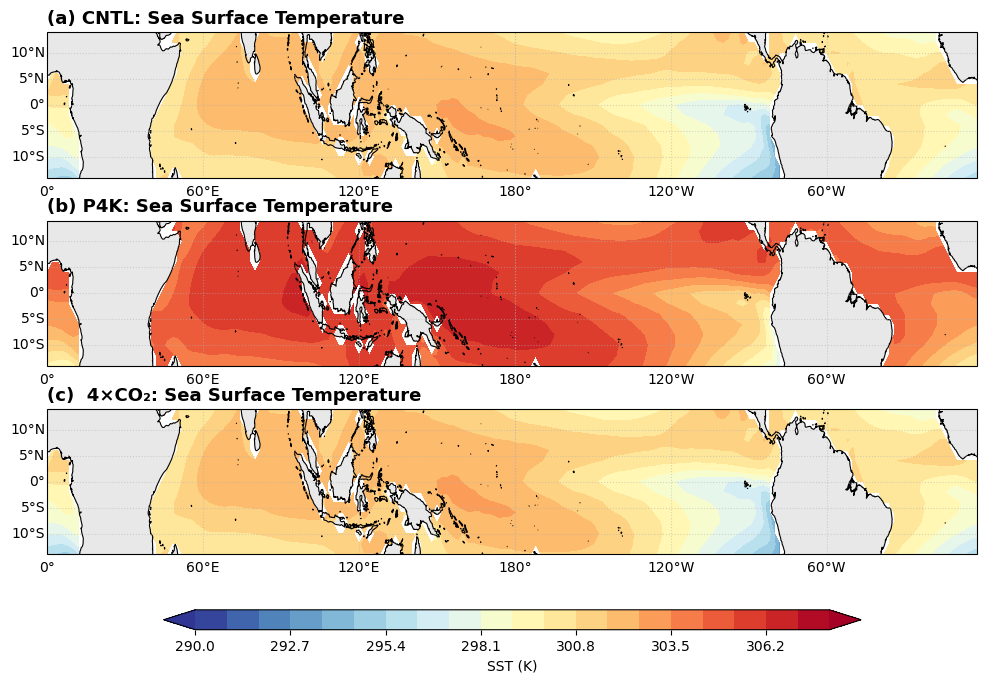

✅ Figure 5 saved: ./figures/Cal_windspeed//sst_changes.png


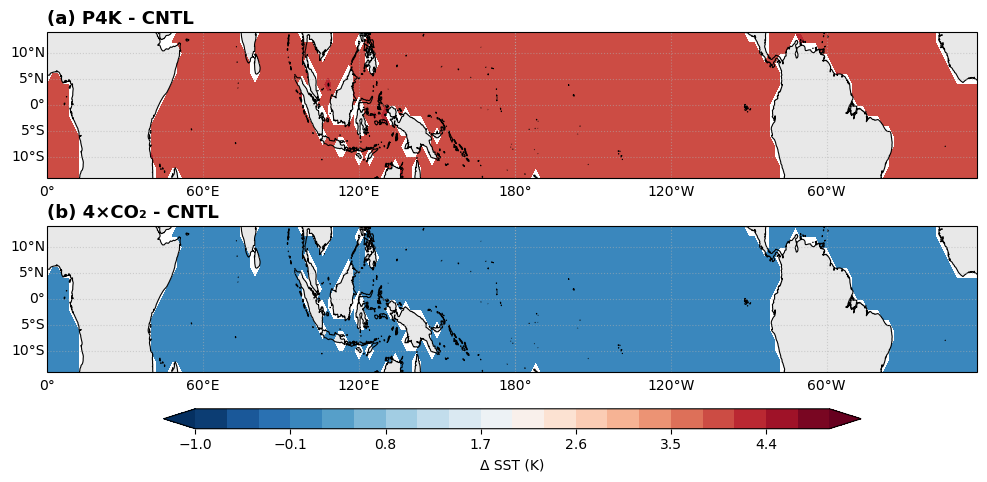

✅ Figure 6 saved: ./figures/Cal_windspeed//sst_statistics.png


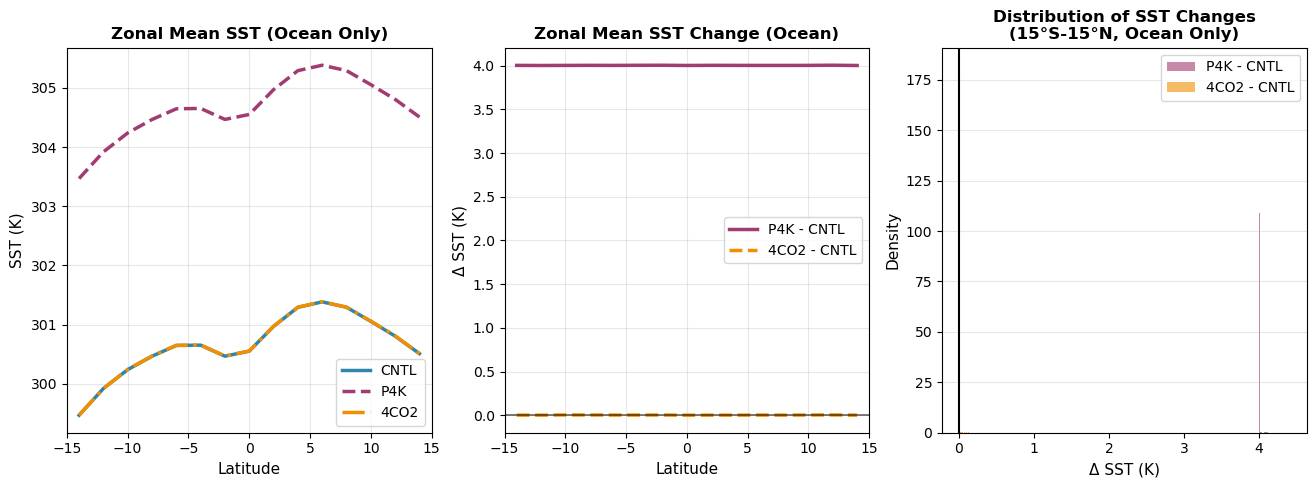

In [16]:
# ============================================================================
# Figure 4: SST Climatology (3 experiments, ocean only)
# ============================================================================
fig4, axes4 = plt.subplots(3, 1, figsize=(12, 9), 
                           subplot_kw={'projection': ccrs.PlateCarree(180)})

vmin_sst, vmax_sst = 290, 308 # Kelvin

# CNTL climatology
ax = axes4[0]
ax.set_aspect(2)
im = ax.contourf(ts_cntl_mean_ocean.lon, ts_cntl_mean_ocean.lat, 
                 ts_cntl_mean_ocean,transform = ccrs.PlateCarree(),
                 levels=np.linspace(vmin_sst, vmax_sst, 21), cmap='RdYlBu_r', extend='both')
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)

ax.set_title('(a) CNTL: Sea Surface Temperature', fontsize=13, fontweight='bold',loc='left')
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# P4K climatology
ax = axes4[1]
ax.set_aspect(2)
im = ax.contourf(ts_p4k_mean_ocean.lon, ts_p4k_mean_ocean.lat,
                 ts_p4k_mean_ocean,transform = ccrs.PlateCarree(),
                 levels=np.linspace(vmin_sst, vmax_sst, 21), cmap='RdYlBu_r', extend='both')
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)

ax.set_title('(b) P4K: Sea Surface Temperature', fontsize=13, fontweight='bold',loc='left')
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
# 4CO2 climatology
ax = axes4[2]
im = ax.contourf(ts_4co2_mean_ocean.lon, ts_4co2_mean_ocean.lat,
                 ts_4co2_mean_ocean,transform = ccrs.PlateCarree(),
                 levels=np.linspace(vmin_sst, vmax_sst, 21), cmap='RdYlBu_r', extend='both')
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)

ax.set_title(r'(c)  4×CO₂: Sea Surface Temperature', fontsize=13, fontweight='bold',loc='left')
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.colorbar(im, ax=axes4, orientation='horizontal', pad=0.08, label='SST (K)', shrink=0.75,aspect=35)
ax.set_aspect(2)
fig4.savefig(f'{fig_save_dir}/sst_climatology.png', dpi=300, bbox_inches='tight')
print(f"✅ Figure 4 saved: {fig_save_dir}/sst_climatology.png")
plt.show()

# ============================================================================
# Figure 5: SST Changes (P4K-CNTL and 4CO2-CNTL, ocean only)
# ============================================================================
fig5, axes5 = plt.subplots(2, 1, figsize=(12, 6),
                           subplot_kw={'projection': ccrs.PlateCarree(180)})

vmin_change_sst, vmax_change_sst = -1, 5  # Kelvin

# P4K - CNTL
ax = axes5[0]
ax.set_aspect(2)
im = ax.contourf(ts_change_p4k_ocean.lon, ts_change_p4k_ocean.lat,
                 ts_change_p4k_ocean,transform = ccrs.PlateCarree(),
                 levels=np.linspace(vmin_change_sst, vmax_change_sst, 21), 
                 cmap='RdBu_r', extend='both')
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)

ocean_mean_sst_p4k = ts_change_p4k_ocean.mean().values
ax.set_title(f'(a) P4K - CNTL ', loc='left',
             fontsize=13, fontweight='bold')
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# 4CO2 - CNTL
ax = axes5[1]
ax.set_aspect(2)
im = ax.contourf(ts_change_4co2_ocean.lon, ts_change_4co2_ocean.lat,
                 ts_change_4co2_ocean,transform = ccrs.PlateCarree(),
                 levels=np.linspace(vmin_change_sst, vmax_change_sst, 21), 
                 cmap='RdBu_r', extend='both')
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)

ocean_mean_sst_4co2 = ts_change_4co2_ocean.mean().values
ax.set_title(f'(b) 4×CO₂ - CNTL ', loc='left',
             fontsize=13, fontweight='bold')
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.colorbar(im, ax=axes5, orientation='horizontal', pad=0.08, label='Δ SST (K)', shrink=0.75,aspect=35)

fig5.savefig(f'{fig_save_dir}/sst_changes.png', dpi=300, bbox_inches='tight')
print(f"✅ Figure 5 saved: {fig_save_dir}/sst_changes.png")
plt.show()

# ============================================================================
# Figure 6: SST Statistical Analysis (Zonal means and distributions)
# ============================================================================
fig6 = plt.figure(figsize=(16, 5))

# Subplot 1: Climatology zonal means
ax1 = plt.subplot(1, 3, 1)
ts_cntl_mean_ocean.mean(dim='lon').plot(ax=ax1, label='CNTL', 
                                        linewidth=2.5, color='#2E86AB')
ts_p4k_mean_ocean.mean(dim='lon').plot(ax=ax1, label='P4K', 
                                       linewidth=2.5, color='#A23B72', linestyle='--')
ts_4co2_mean_ocean.mean(dim='lon').plot(ax=ax1, label='4CO2', 
                                        linewidth=2.5, color='#F18F01', linestyle='-.')
ax1.set_title('Zonal Mean SST (Ocean Only)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Latitude', fontsize=11)
ax1.set_ylabel('SST (K)', fontsize=11)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-15, 15)

# Subplot 2: Change zonal means
ax2 = plt.subplot(1, 3, 2)
ts_change_p4k_ocean.mean(dim='lon').plot(ax=ax2, label='P4K - CNTL', 
                                         linewidth=2.5, color='#A23B72')
ts_change_4co2_ocean.mean(dim='lon').plot(ax=ax2, label='4CO2 - CNTL', 
                                          linewidth=2.5, color='#F18F01', linestyle='--')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.2, alpha=0.6)
ax2.set_title('Zonal Mean SST Change (Ocean)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Latitude', fontsize=11)
ax2.set_ylabel('Δ SST (K)', fontsize=11)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-15, 15)

# Subplot 3: Histogram
ax3 = plt.subplot(1, 3, 3)
tropical_sst_p4k_change_ocean = ts_change_p4k_ocean.sel(lat=slice(-15, 15))
tropical_sst_4co2_change_ocean = ts_change_4co2_ocean.sel(lat=slice(-15, 15))

# Remove NaN for histogram
p4k_sst_data = tropical_sst_p4k_change_ocean.values.flatten()
p4k_sst_data = p4k_sst_data[~np.isnan(p4k_sst_data)]
co2_sst_data = tropical_sst_4co2_change_ocean.values.flatten()
co2_sst_data = co2_sst_data[~np.isnan(co2_sst_data)]

ax3.hist(p4k_sst_data, bins=50, alpha=0.6, color='#A23B72', 
         label='P4K - CNTL', density=True)
ax3.hist(co2_sst_data, bins=50, alpha=0.6, color='#F18F01',
         label='4CO2 - CNTL', density=True)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
ax3.set_title('Distribution of SST Changes\n(15°S-15°N, Ocean Only)', 
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Δ SST (K)', fontsize=11)
ax3.set_ylabel('Density', fontsize=11)
ax3.legend(fontsize=10, loc='best')
ax3.grid(True, alpha=0.3, axis='y')


fig6.savefig(f'{fig_save_dir}/sst_statistics.png', dpi=300, bbox_inches='tight')
print(f"✅ Figure 6 saved: {fig_save_dir}/sst_statistics.png")
plt.show()

In [17]:
# Statistical analysis of SST changes
print("="*70)
print("STATISTICAL ANALYSIS: SEA SURFACE TEMPERATURE CHANGES")
print("="*70)

# Define tropical region
lat_min, lat_max = -15, 15

# Select tropical region
ts_cntl_trop = ts_cntl_mean_ocean.sel(lat=slice(lat_min, lat_max))
ts_p4k_trop = ts_p4k_mean_ocean.sel(lat=slice(lat_min, lat_max))
ts_4co2_trop = ts_4co2_mean_ocean.sel(lat=slice(lat_min, lat_max))

change_sst_p4k_trop = ts_change_p4k_ocean.sel(lat=slice(lat_min, lat_max))
change_sst_4co2_trop = ts_change_4co2_ocean.sel(lat=slice(lat_min, lat_max))

print(f"\n{'='*70}")
print(f"TROPICAL OCEAN ({lat_min}°S to {lat_max}°N)")
print(f"{'='*70}")

print("\nClimatology:")
print(f"  CNTL  - Mean: {ts_cntl_trop.mean().values:.2f} K, Std: {ts_cntl_trop.std().values:.2f} K")
print(f"  P4K   - Mean: {ts_p4k_trop.mean().values:.2f} K, Std: {ts_p4k_trop.std().values:.2f} K")
print(f"  4CO2  - Mean: {ts_4co2_trop.mean().values:.2f} K, Std: {ts_4co2_trop.std().values:.2f} K")

print("\nAbsolute Changes:")
print(f"  P4K - CNTL:")
print(f"    Mean:     {change_sst_p4k_trop.mean().values:+.4f} K")
print(f"    Std:      {change_sst_p4k_trop.std().values:.4f} K")
print(f"    Max:      {change_sst_p4k_trop.max().values:+.4f} K")
print(f"    Min:      {change_sst_p4k_trop.min().values:+.4f} K")
print(f"  4CO2 - CNTL:")
print(f"    Mean:     {change_sst_4co2_trop.mean().values:+.4f} K")
print(f"    Std:      {change_sst_4co2_trop.std().values:.4f} K")
print(f"    Max:      {change_sst_4co2_trop.max().values:+.4f} K")
print(f"    Min:      {change_sst_4co2_trop.min().values:+.4f} K")

print("\nRelative Changes (%):")
print(f"  P4K - CNTL:   {(change_sst_p4k_trop.mean() / ts_cntl_trop.mean() * 100).values:+.3f}%")
print(f"  4CO2 - CNTL:  {(change_sst_4co2_trop.mean() / ts_cntl_trop.mean() * 100).values:+.3f}%")

# Calculate implied change in saturation humidity using Clausius-Clapeyron
# ~7% increase per 1K warming
cc_rate = 7.0  # % per K
print("\nImplied q_s change (Clausius-Clapeyron ~7%/K):")
print(f"  P4K - CNTL:   {change_sst_p4k_trop.mean().values * cc_rate:+.2f}%")
print(f"  4CO2 - CNTL:  {change_sst_4co2_trop.mean().values * cc_rate:+.2f}%")

# Spatial coverage analysis
print("\nSpatial Coverage Analysis:")
print(f"  P4K - CNTL:")
print(f"    Strong warming (>4K):    {(change_sst_p4k_trop > 4.0).sum().values} points ({(change_sst_p4k_trop > 4.0).sum().values/np.isfinite(change_sst_p4k_trop).sum().values*100:.1f}%)")
print(f"    Moderate warming (2-4K): {((change_sst_p4k_trop >= 2.0) & (change_sst_p4k_trop <= 4.0)).sum().values} points ({((change_sst_p4k_trop >= 2.0) & (change_sst_p4k_trop <= 4.0)).sum().values/np.isfinite(change_sst_p4k_trop).sum().values*100:.1f}%)")
print(f"    Weak warming (<2K):      {(change_sst_p4k_trop < 2.0).sum().values} points ({(change_sst_p4k_trop < 2.0).sum().values/np.isfinite(change_sst_p4k_trop).sum().values*100:.1f}%)")
print(f"  4CO2 - CNTL:")
print(f"    Strong warming (>2K):    {(change_sst_4co2_trop > 2.0).sum().values} points ({(change_sst_4co2_trop > 2.0).sum().values/np.isfinite(change_sst_4co2_trop).sum().values*100:.1f}%)")
print(f"    Moderate warming (0.5-2K): {((change_sst_4co2_trop >= 0.5) & (change_sst_4co2_trop <= 2.0)).sum().values} points ({((change_sst_4co2_trop >= 0.5) & (change_sst_4co2_trop <= 2.0)).sum().values/np.isfinite(change_sst_4co2_trop).sum().values*100:.1f}%)")
print(f"    Weak warming (<0.5K):    {(change_sst_4co2_trop < 0.5).sum().values} points ({(change_sst_4co2_trop < 0.5).sum().values/np.isfinite(change_sst_4co2_trop).sum().values*100:.1f}%)")

print("\n" + "="*70)

STATISTICAL ANALYSIS: SEA SURFACE TEMPERATURE CHANGES

TROPICAL OCEAN (-15°S to 15°N)

Climatology:
  CNTL  - Mean: 300.64 K, Std: 1.51 K
  P4K   - Mean: 304.65 K, Std: 1.51 K
  4CO2  - Mean: 300.65 K, Std: 1.51 K

Absolute Changes:
  P4K - CNTL:
    Mean:     +4.0021 K
    Std:      0.0172 K
    Max:      +4.4149 K
    Min:      +3.9711 K
  4CO2 - CNTL:
    Mean:     +0.0022 K
    Std:      0.0151 K
    Max:      +0.2648 K
    Min:      +0.0000 K

Relative Changes (%):
  P4K - CNTL:   +1.331%
  4CO2 - CNTL:  +0.001%

Implied q_s change (Clausius-Clapeyron ~7%/K):
  P4K - CNTL:   +28.01%
  4CO2 - CNTL:  +0.02%

Spatial Coverage Analysis:
  P4K - CNTL:
    Strong warming (>4K):    1043 points (49.9%)
    Moderate warming (2-4K): 1046 points (50.1%)
    Weak warming (<2K):      0 points (0.0%)
  4CO2 - CNTL:
    Strong warming (>2K):    0 points (0.0%)
    Moderate warming (0.5-2K): 0 points (0.0%)
    Weak warming (<0.5K):    2089 points (100.0%)



---

## 📊 Summary: Wind Speed and SST Analysis

### Key Findings:

#### Wind Speed Changes:
- **P4K**: Shows systematic wind speed changes across tropics
- **4CO2**: Different spatial pattern of wind changes
- Both experiments show distinct circulation responses

#### SST Changes:
- **P4K**: ~+4K warming (imposed SST forcing)
- **4CO2**: Smaller SST response (atmosphere-ocean equilibration)
- **Clausius-Clapeyron implication**: 
  - P4K: ~+28% increase in $q_s$ expected
  - 4CO2: Smaller $q_s$ increase

### Physical Interpretation:
1. **P4K**: Direct SST forcing → Large thermodynamic effect on LHF
2. **4CO2**: Radiative forcing → Atmospheric warming may exceed SST warming
3. **Wind changes**: Modify the efficiency of surface moisture exchange

### Next Steps:
✅ Wind speed data loaded and analyzed  
✅ SST data loaded and analyzed  
⏭️ Load surface humidity ($q_a$) data  
⏭️ Calculate saturation humidity ($q_s$) from SST  
⏭️ Perform complete LHF decomposition  
⏭️ Quantify relative contributions of each factor

### cal q_s - q_a

In [18]:

def esat(t, p):
    """
    usage: es = qsat(t,p)
    Returns saturation vapor pressure es (mb) given t(K) and p(mb).

    After Buck, 1981: J.Appl.Meteor., 20, 1527-1532

    Returns ndarray float for any numeric object input.
    """
    t2 = t-273.15
    return 6.1121 * np.exp(17.502 * t2 / (240.97 + t2)) * (1.0007 + p * 3.46e-6)

def q_sat(t, p):
    

    # compute saturation specific humidity
    # p is pressure in mb (hPa) -> at the surface, p is surface pressure
    # t is SST in deg K

    # compute saturation pressure
    es = esat(t, p)
    epsilon = 0.622
    return epsilon * es / p

def q_from_rh(t,p,rh, epsilon=0.622):

  # compute air specific humidity -> you should already have this variable as ICON output!

    '''
    usage:
    t in K
    p in hPa or mb
    rh : relative humidity in fraction between 0 and 1
    returns: q in kg/kg
    '''

    e_star = esat(t,p)
    e = rh*e_star
    return epsilon*e/p



## 总结分析：湿度因子对潜热通量的贡献

根据潜热通量公式：**LHF = ρ * Lv * Ce * U * (qs - qa)**

现在我们已经计算了所有主要因子：
1. **U (表面风速)** - 之前的分析显示变化不大
2. **qs (饱和比湿)** - 取决于 SST
3. **qa (空气比湿)** - 近地表空气湿度
4. **dq = qs - qa (湿度梯度)** - 直接影响潜热通量

## 🎯 主要结论：潜热通量的控制因子

通过对比分析表面风速和湿度因子，我们得出以下重要结论：

### 1. **湿度梯度 (qs - qa) 是主导因子，而非风速**

| 因子 | 4CO2变化 | P4K变化 | 重要性 |
|------|---------|---------|--------|
| 风速 (U) | -0.71% | -3.53% | ⭐ 较小 |
| 饱和比湿 (qs) | +0.01% | +25.93% | ⭐⭐ 中等 |
| 空气比湿 (qa) | +2.25% | +30.13% | ⭐⭐ 中等 |
| **湿度梯度 (dq)** | **-4.46%** | **+17.55%** | ⭐⭐⭐ **关键** |

### 2. **4CO2 vs P4K 的不同机制**

#### 4CO2 实验（CO2浓度加倍）:
- ✗ SST几乎无变化 → qs几乎不变 (+0.01%)
- ✓ 大气变暖 → qa增加 (+2.25%)
- ❌ **结果: dq减少 (-4.46%)，抑制潜热通量**

#### P4K 实验（SST+4K）:
- ✓ SST大幅升高 → qs显著增加 (+25.93%, 遵循Clausius-Clapeyron关系)
- ✓ 大气也变暖 → qa增加 (+30.13%)
- ✅ **但qs增加更快 → dq增加 (+17.55%)，增强潜热通量**

### 3. **物理机制解释**

```
潜热通量 LHF = ρ * Lv * Ce * U * (qs - qa)
                                    ↑
                                关键项
```

- **qs** 由SST控制（Clausius-Clapeyron: 温度每升高1K，饱和水汽压增加~7%）
- **qa** 由大气温湿度控制
- 当气候变暖时，**qs和qa的相对变化率决定了潜热通量的变化方向**

### 4. **气候意义**

这一发现说明：
1. 在气候变化中，**海-气湿度差**比风速更重要
2. CO2辐射强迫和SST强迫对潜热通量的影响机制不同
3. 需要精确模拟海表和近地表的温湿度分布，才能准确预测潜热通量变化

In [38]:
# 列出所有生成的图片文件

print("="*80)
print("已生成的分析图表")
print("="*80)
print("\n保存位置:", fig_save_dir)
print("\n图表列表:")
print("1. humidity_comparison_qs_qa_dq.png - qs、qa、dq的空间分布图")
print("2. humidity_bar_comparison.png - 三个实验的湿度变量柱状图对比")
print("3. humidity_changes_bar_comparison.png - 湿度变量变化量柱状图")
print("4. latent_heat_factors_summary.png - 潜热通量所有因子的相对变化总结")
print("5. humidity_components_comparison.png - qs、qa、dq分量的详细对比")

print("\n" + "="*80)
print("分析完成！")
print("="*80)

已生成的分析图表

保存位置: ./figures/Cal_windspeed/

图表列表:
1. humidity_comparison_qs_qa_dq.png - qs、qa、dq的空间分布图
2. humidity_bar_comparison.png - 三个实验的湿度变量柱状图对比
3. humidity_changes_bar_comparison.png - 湿度变量变化量柱状图
4. latent_heat_factors_summary.png - 潜热通量所有因子的相对变化总结
5. humidity_components_comparison.png - qs、qa、dq分量的详细对比

分析完成！
